In [2]:
! pip show protobuf

Name: protobuf
Version: 6.33.0
Summary: 
Home-page: https://developers.google.com/protocol-buffers/
Author: protobuf@googlegroups.com
Author-email: protobuf@googlegroups.com
License: 3-Clause BSD License
Location: /usr/local/lib/python3.10/dist-packages
Requires: 
Required-by: tensorboard, tensorflow, yfinance


In [3]:
! pip show onnx

In [4]:
! pip show onnxruntime

In [5]:
! pip show tf2onnx

# 이메일 분류 AI 플랫폼

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re

import warnings
warnings.filterwarnings('ignore', category=pd.errors.DtypeWarning)

# DataLoad

In [2]:
df = pd.read_csv('../data/email_data.csv', parse_dates=["received_at"])
df_raw = pd.read_csv('../data/raw_email_data_date_fixed.csv', parse_dates=["received_at"])

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12201 entries, 0 to 12200
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   email_id        12201 non-null  int64         
 1   thread_id       12201 non-null  int64         
 2   received_at     12201 non-null  datetime64[ns]
 3   sender          12201 non-null  object        
 4   recipient       12201 non-null  object        
 5   title           12201 non-null  object        
 6   content         12201 non-null  object        
 7   has_attachment  12201 non-null  int64         
 8   mail_channel    12201 non-null  int64         
 9   label_dept      12201 non-null  int64         
 10  priority_level  12201 non-null  int64         
 11  sentiment       12201 non-null  int64         
 12  is_complaint    12201 non-null  int64         
 13  assignee        12201 non-null  int64         
 14  is_spam         12201 non-null  int64         
dtypes:

In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1768 entries, 0 to 1767
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   email_id        1768 non-null   int64         
 1   thread_id       1768 non-null   int64         
 2   received_at     1768 non-null   datetime64[ns]
 3   sender          1768 non-null   object        
 4   recipient       1768 non-null   object        
 5   title           1768 non-null   object        
 6   content         1768 non-null   object        
 7   has_attachment  1768 non-null   int64         
 8   mail_channel    1768 non-null   int64         
 9   label_dept      1768 non-null   int64         
 10  priority_level  1768 non-null   int64         
 11  sentiment       1768 non-null   int64         
 12  is_complaint    1768 non-null   int64         
 13  assignee        1768 non-null   int64         
 14  is_spam         1768 non-null   int64         
 15  text

In [5]:
len(df)

12201

In [6]:
# def drop_invalid_recipient(df: pd.DataFrame) -> pd.DataFrame:
#     mask = df["recipient"].astype(str).str.endswith("@ssacorp.com")
#     print("✅ 정상 recipient:", mask.sum())
#     print("⚠️ 드랍되는 row:", (~mask).sum())
#     return df.loc[mask].copy()

# df_raw_clean = drop_invalid_recipient(df_raw)
# df_raw_clean.to_csv('../data/raw_email_data_date_fixed.csv')

In [7]:
df.head(1)

,email_id,thread_id,received_at,sender,recipient,title,content,has_attachment,mail_channel,label_dept,priority_level,sentiment,is_complaint,assignee,is_spam
0,10001,1,2024-07-10 10:00:00,dev.seojun@ssacorp.com,service.minji@ssacorp.com,API 서버 에러 로그 분석 요청,"안녕하세요, 서비스팀 민지님. 어제부터 API 서버에서 간헐적으로 에러가 발생하고 ...",1,1,0,2,1,0,0,0


## 원본, raw데이터 비교

clean shape: (12201, 15)
raw   shape: (1768, 21)
비교할 컬럼: ['mail_channel', 'label_dept', 'priority_level', 'sentiment', 'is_complaint', 'assignee', 'has_attachment', 'is_spam']


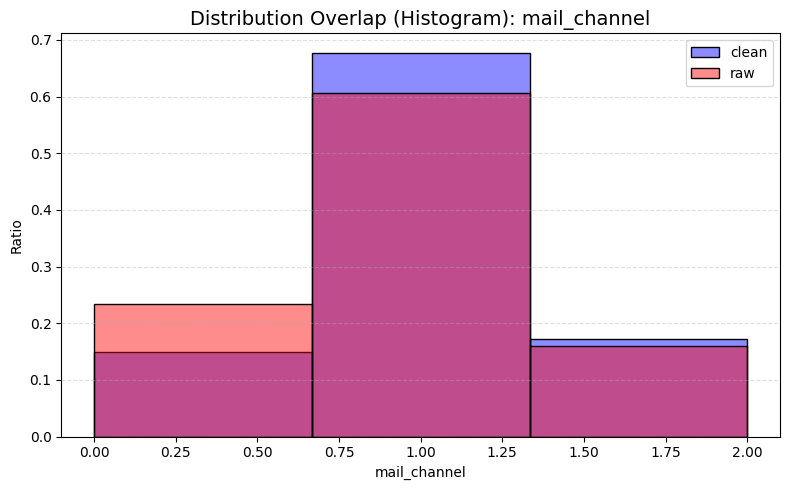

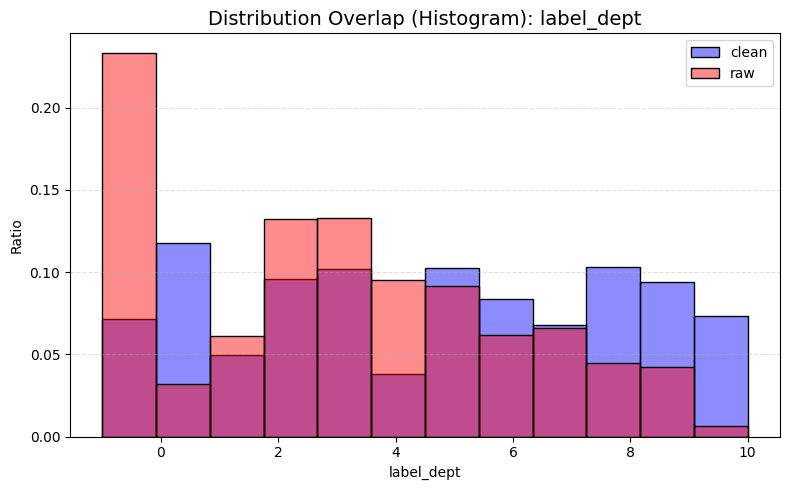

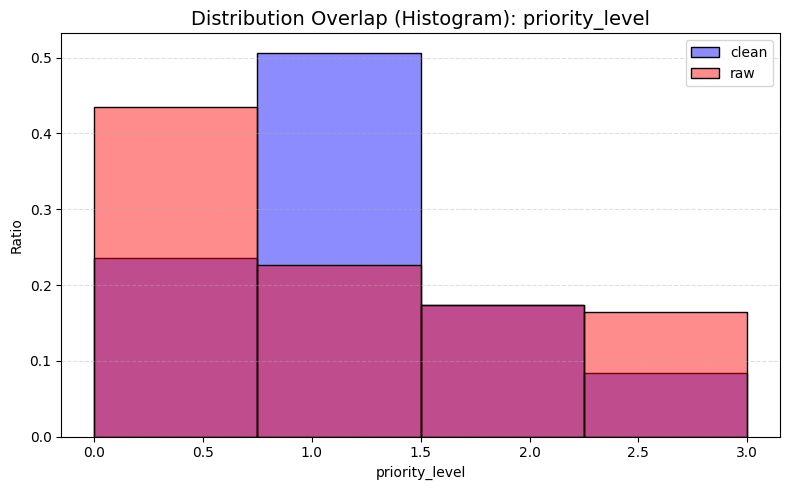

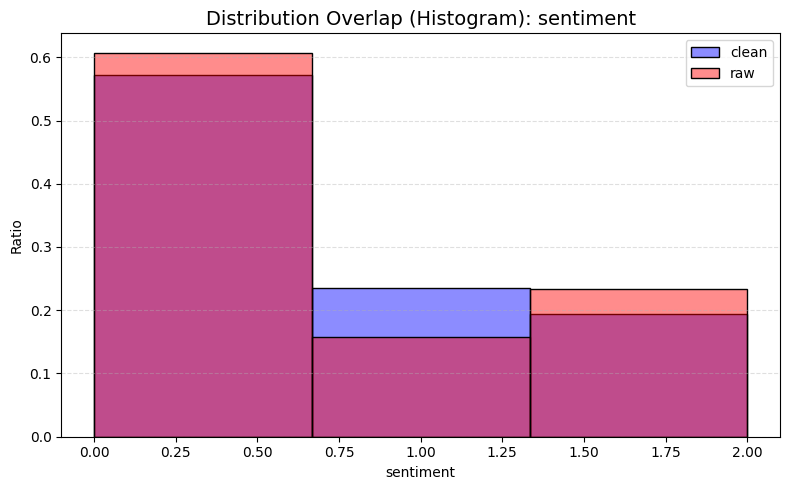

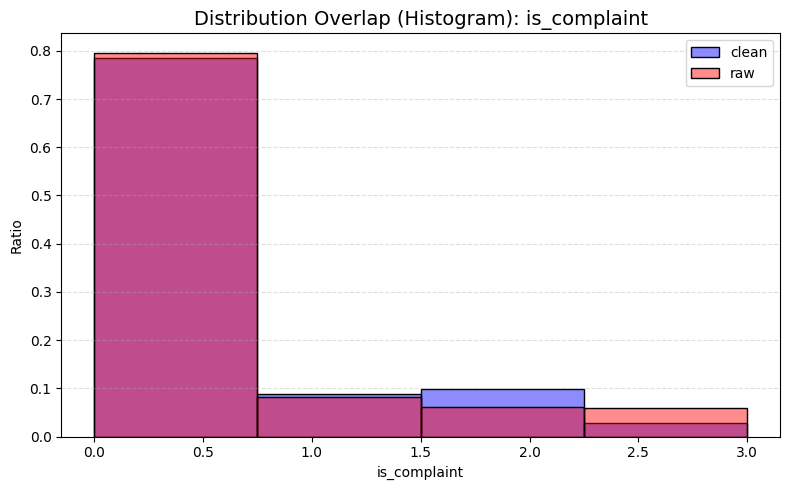

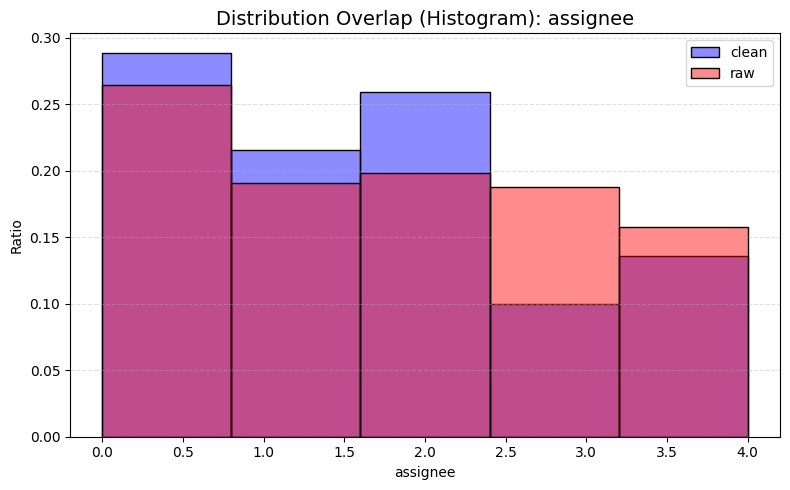

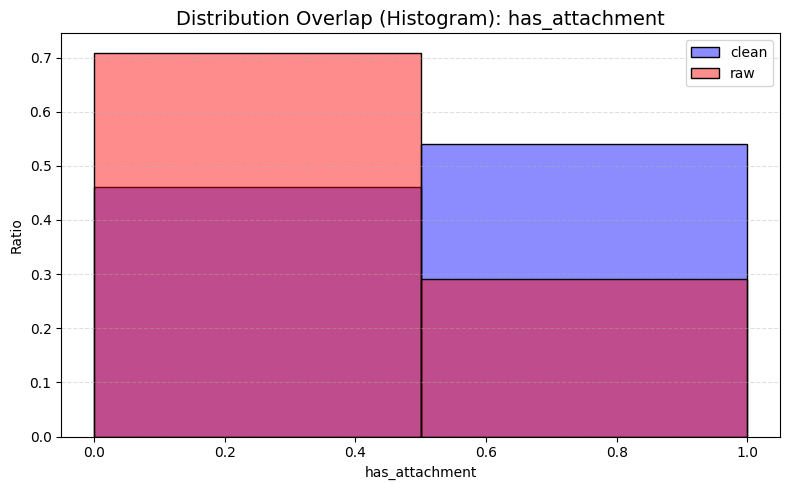

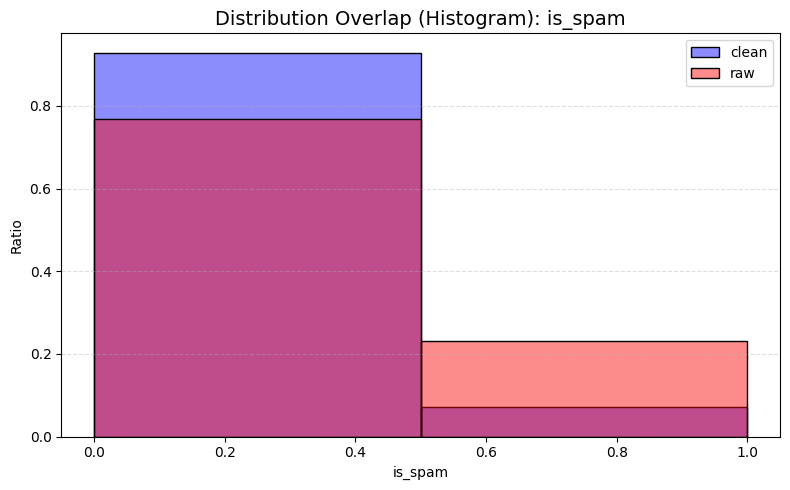

In [8]:
print('clean shape:', df.shape)
print('raw   shape:', df_raw.shape)

# 비교할 컬럼
cols_to_compare = [
    'mail_channel',
    'label_dept',
    'priority_level',
    'sentiment',
    'is_complaint',
    'assignee',
    'has_attachment',
    'is_spam'
]

cols_to_compare = [
    c for c in cols_to_compare
    if (c in df.columns) and (c in df_raw.columns)
]

print('비교할 컬럼:', cols_to_compare)

# 🔥 히스토그램 형태로 clean vs raw 겹쳐서 그리기
for col in cols_to_compare:
    plt.figure(figsize=(8, 5))

    # Clean histogram
    sns.histplot(
        df[col],
        bins=len(df[col].unique()),
        stat='probability',
        color='blue',
        alpha=0.45,
        label='clean'
    )

    # Raw histogram
    sns.histplot(
        df_raw[col],
        bins=len(df_raw[col].unique()),
        stat='probability',
        color='red',
        alpha=0.45,
        label='raw'
    )

    plt.title(f'Distribution Overlap (Histogram): {col}', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Ratio')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

## 스키마 검증

### 값 범위 체크

In [9]:
def check_ranges(df: pd.DataFrame):
    assert df["priority_level"].between(0, 3).all(), "priority_level 범위 오류"
    assert df["sentiment"].between(0, 2).all(), "sentiment 범위 오류"
    assert df["is_complaint"].between(0, 3).all(), "is_complaint 범위 오류"
    assert df["assignee"].between(0, 4).all(), "assignee 범위 오류"
    
    # label_dept는 -1(스팸) 또는 0~10
    valid_dept = df["label_dept"].isin([-1] + list(range(0, 11)))
    assert valid_dept.all(), "label_dept 범위 오류"


### 스팸 규칙 체크

In [10]:
def check_spam_rules(df: pd.DataFrame):
    spam = df[df["is_spam"] == 1]
    if not spam.empty:
        assert (spam["mail_channel"] == 0).all(), "스팸인데 mail_channel != 0 존재"
        assert (spam["label_dept"] == -1).all(), "스팸인데 label_dept != -1 존재"


### 도메인 규칙 체크

In [11]:
def check_domains(df: pd.DataFrame):
    # 사내 직원이 받는 메일 → recipient는 항상 @ssacorp.com
    assert df["recipient"].str.endswith("@ssacorp.com").all(), "recipient 중 사내 도메인 아님"
    
    # 스팸은 sender가 일반 도메인인지 대략 체크
    spam = df[df["is_spam"] == 1]
    common_spam_domains = ("gmail.com", "naver.com", "daum.net", "yahoo.com")
    if not spam.empty:
        mask = spam["sender"].str.endswith(common_spam_domains)
        # 100% 일치까지는 안봐도 되니, 비율 정도 확인
        spam_ratio = mask.mean()
        print(f"[INFO] 스팸 중 일반 도메인 비율: {spam_ratio:.2%}")


### 중복된 title, content 체크

In [12]:
def check_duplicates(df: pd.DataFrame):
    # email_id는 고유해야 함
    
    
    # title+content 완전 동일한 행 수
    dup_tc = df.duplicated(subset=["title", "content"]).sum()
    print(f"[INFO] title+content 완전 중복 행 개수: {dup_tc}")

### 체크 실행

In [13]:
def validate_email_schema(df: pd.DataFrame):
    print("[STEP] 값 범위 체크")
    check_ranges(df)
    print("  ✔ OK")
    
    print("[STEP] 스팸 규칙 체크")
    check_spam_rules(df)
    print("  ✔ OK")
    
    print("[STEP] 도메인 규칙 체크")
    check_domains(df)
    
    print("[STEP] 중복 여부 체크")
    check_duplicates(df)
    print("  ✔ Done")


In [14]:
validate_email_schema(df_raw)

[STEP] 값 범위 체크
  ✔ OK
[STEP] 스팸 규칙 체크
  ✔ OK
[STEP] 도메인 규칙 체크
[INFO] 스팸 중 일반 도메인 비율: 95.37%
[STEP] 중복 여부 체크
[INFO] title+content 완전 중복 행 개수: 1
  ✔ Done


In [15]:
validate_email_schema(df)

[STEP] 값 범위 체크
  ✔ OK
[STEP] 스팸 규칙 체크
  ✔ OK
[STEP] 도메인 규칙 체크
[INFO] 스팸 중 일반 도메인 비율: 100.00%
[STEP] 중복 여부 체크
[INFO] title+content 완전 중복 행 개수: 6
  ✔ Done


# 1차 전처리 & 가공

## title, content 통합 피처 생성
* 제목과 본문을 붙여서 더 정확한 의미를 이해하게 하기 위해

In [16]:
def build_text_column(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # 기본 결합
    text = df["title"].astype(str) + "\n" + df["content"].astype(str)
    
    # 연속 공백, 줄바꿈 최소 정리 (너무 과한 정규식은 X)
    text = text.str.replace(r"\s+", " ", regex=True)
    
    df["text"] = text.str.strip()
    return df

df = build_text_column(df)
df_raw = build_text_column(df_raw)

In [17]:
df['text']

0        API 서버 에러 로그 분석 요청 안녕하세요, 서비스팀 민지님. 어제부터 API 서...
1        신규 캠페인 관련 영업팀 협조 요청 안녕하세요, 영업팀 지훈님. 이번에 진행하는 신...
2        2분기 실적 보고서 검토 요청 안녕하세요, 경영팀 동현님. 2분기 실적 보고서를 첨...
3        개발팀 인사 발령 안내 안녕하세요, 개발팀 서준님. 금번 인사 발령에 따라 개발팀에...
4        신규 UI/UX 디자인 시안 검토 요청 안녕하세요, 디자인팀 지은님. 현재 기획 중...
                               ...                        
12196    세금계산서 발행 관련 협조 요청 강소현님, 안녕하세요. 거래처 솔루텍에서 세금계산서...
12197    신규 UI 디자인 시안 검토 요청 정현우님, 안녕하세요. 신규 UI 디자인 시안이 ...
12198    인사 발령에 대한 불만 사항 접수 박재현님, 안녕하세요. 이번 인사 발령에 대한 불...
12199    서버 장애 발생 및 긴급 복구 요청 박은지님, 안녕하세요. 현재 주 서버에서 장애가...
12200    업무 협조 요청에 대한 지연 한지원님, 안녕하세요. 지난주 요청드린 업무 협조 건에...
Name: text, Length: 12201, dtype: object

In [18]:
df_raw['text']

0       🎉 축하합니다! 특별 할인 쿠폰 증정! 데이비드님, 안녕하세요! 특별한 당신만을 위...
1       !!! 놀라운 할인 기회 !!! 지금 바로 클릭하세요! 최고의 상품을 최저가에 만나...
2       🎉 놀라운 할인! 지금 바로 확인하세요! 지금 가입하시면 특별한 혜택이 쏟아집니다!...
3       🎉 놀라운 할인! 지금 바로 확인하세요! 지금 바로 클릭! 특별한 가격으로 최고의 ...
4       [광고] 억대 연봉의 기회! 지금 바로 투자하세요! 단기간에 큰 수익을 올릴 수 있...
                              ...                        
1763    Re: Re: 프로젝트 업데이트 존, 네 알겠습니다. 다음 주 화요일에 회의 가능합...
1764    휴가 신청 매니저님, 다음 주에 개인적인 사정으로 휴가를 신청합니다. 2024년 2...
1765    대박! 꽁돈이 쏟아집니다! 지금 가입하면 즉시 10만원 지급! 친구를 초대하면 추가...
1766       광고: 놀라운 상품! 지금 구매하시면 놀라운 상품을 드립니다. 절대 놓치지 마세요!
1767    사내 카페 개선 설문조사 안녕하세요, SSA Corp. 임직원 여러분. 사내 카페 ...
Name: text, Length: 1768, dtype: object

## 시간/텍스트 길이 기반 피처 추가
* 긴급도/업무량 패턴분석에 사용
* 직원 성실도 or 업무량 시계열
* 시간별 메일 패턴 분석시 사용

In [19]:
def add_basic_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # 시간 관련
    df["received_at"] = pd.to_datetime(df["received_at"])
    df["hour"] = df["received_at"].dt.hour
    df["dayofweek"] = df["received_at"].dt.dayofweek  # 0=월, 6=일
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)
    
    # 텍스트 길이 관련
    df["text_len_char"] = df["text"].str.len()
    df["text_len_word"] = df["text"].str.split().str.len()
    
    return df

df = add_basic_features(df)
df_raw = add_basic_features(df_raw)

In [20]:
df.head(1)

,email_id,thread_id,received_at,sender,recipient,title,content,has_attachment,mail_channel,label_dept,...,sentiment,is_complaint,assignee,is_spam,text,hour,dayofweek,is_weekend,text_len_char,text_len_word
0,10001,1,2024-07-10 10:00:00,dev.seojun@ssacorp.com,service.minji@ssacorp.com,API 서버 에러 로그 분석 요청,"안녕하세요, 서비스팀 민지님. 어제부터 API 서버에서 간헐적으로 에러가 발생하고 ...",1,1,0,...,1,0,0,0,"API 서버 에러 로그 분석 요청 안녕하세요, 서비스팀 민지님. 어제부터 API 서...",10,2,0,132,29


In [21]:
df_raw.head(1)

,email_id,thread_id,received_at,sender,recipient,title,content,has_attachment,mail_channel,label_dept,...,sentiment,is_complaint,assignee,is_spam,text,hour,dayofweek,is_weekend,text_len_char,text_len_word
0,11663,0,2025-01-18 04:02:13,event@gmail.com,david.choi@ssacorp.com,🎉 축하합니다! 특별 할인 쿠폰 증정!,"데이비드님, 안녕하세요! 특별한 당신만을 위한 할인 쿠폰을 드립니다. 지금 바로 접...",0,0,-1,...,0,0,0,1,"🎉 축하합니다! 특별 할인 쿠폰 증정! 데이비드님, 안녕하세요! 특별한 당신만을 위...",4,5,1,127,28


## 스팸/정상 분리, 학습용 DF

In [22]:
def split_spam_normal(df: pd.DataFrame):
    df_spam = df[df["is_spam"] == 1].copy()
    df_normal = df[df["is_spam"] == 0].copy()
    
    # 정상 메일에서도 label_dept = -1인 건 제거 (이론상 없어야 하지만 방지차원)
    df_normal = df_normal[df_normal["label_dept"] >= 0].copy()
    
    return df_normal, df_spam

df_normal, df_spam = split_spam_normal(df)
df_raw_normal, df_raw_spam = split_spam_normal(df_raw)
print(df_normal.shape, df_spam.shape)
print(df_raw_normal.shape, df_raw_spam.shape)


(11331, 21) (868, 21)
(1355, 21) (410, 21)


In [23]:
df_normal['is_spam'].unique()

array([0])

In [24]:
df_spam['is_spam'].unique()

array([1])

## 첫번째 전처리 파이프라인 한방 코드

In [25]:
# def preprocess_stage1(path: str | Path):
#     # 1. 로드
#     df_raw = load_email_data(path)
    
#     # 2. 타입 캐스팅
#     df = cast_types(df_raw)
    
#     # 3. 스키마/규칙 검증
#     validate_email_schema(df)
    
#     # 4. 텍스트 컬럼 생성
#     df = build_text_column(df)
    
#     # 5. 기본 피처 추가
#     df = add_basic_features(df)
    
#     # 6. 스팸/정상 분리
#     df_normal, df_spam = split_spam_normal(df)
    
#     return df, df_normal, df_spam

# df_all, df_normal, df_spam = preprocess_stage1(DATA_PATH)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12201 entries, 0 to 12200
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   email_id        12201 non-null  int64         
 1   thread_id       12201 non-null  int64         
 2   received_at     12201 non-null  datetime64[ns]
 3   sender          12201 non-null  object        
 4   recipient       12201 non-null  object        
 5   title           12201 non-null  object        
 6   content         12201 non-null  object        
 7   has_attachment  12201 non-null  int64         
 8   mail_channel    12201 non-null  int64         
 9   label_dept      12201 non-null  int64         
 10  priority_level  12201 non-null  int64         
 11  sentiment       12201 non-null  int64         
 12  is_complaint    12201 non-null  int64         
 13  assignee        12201 non-null  int64         
 14  is_spam         12201 non-null  int64         
 15  te

# Core Multi-Task Email Classifier 전처리
* 전처리 후에 나누면 validation 보고 학습될수있어서 나누고 전처리 진행
* spam이 아닌 정상메일로 학습 진행

<Figure size 1600x1200 with 0 Axes>

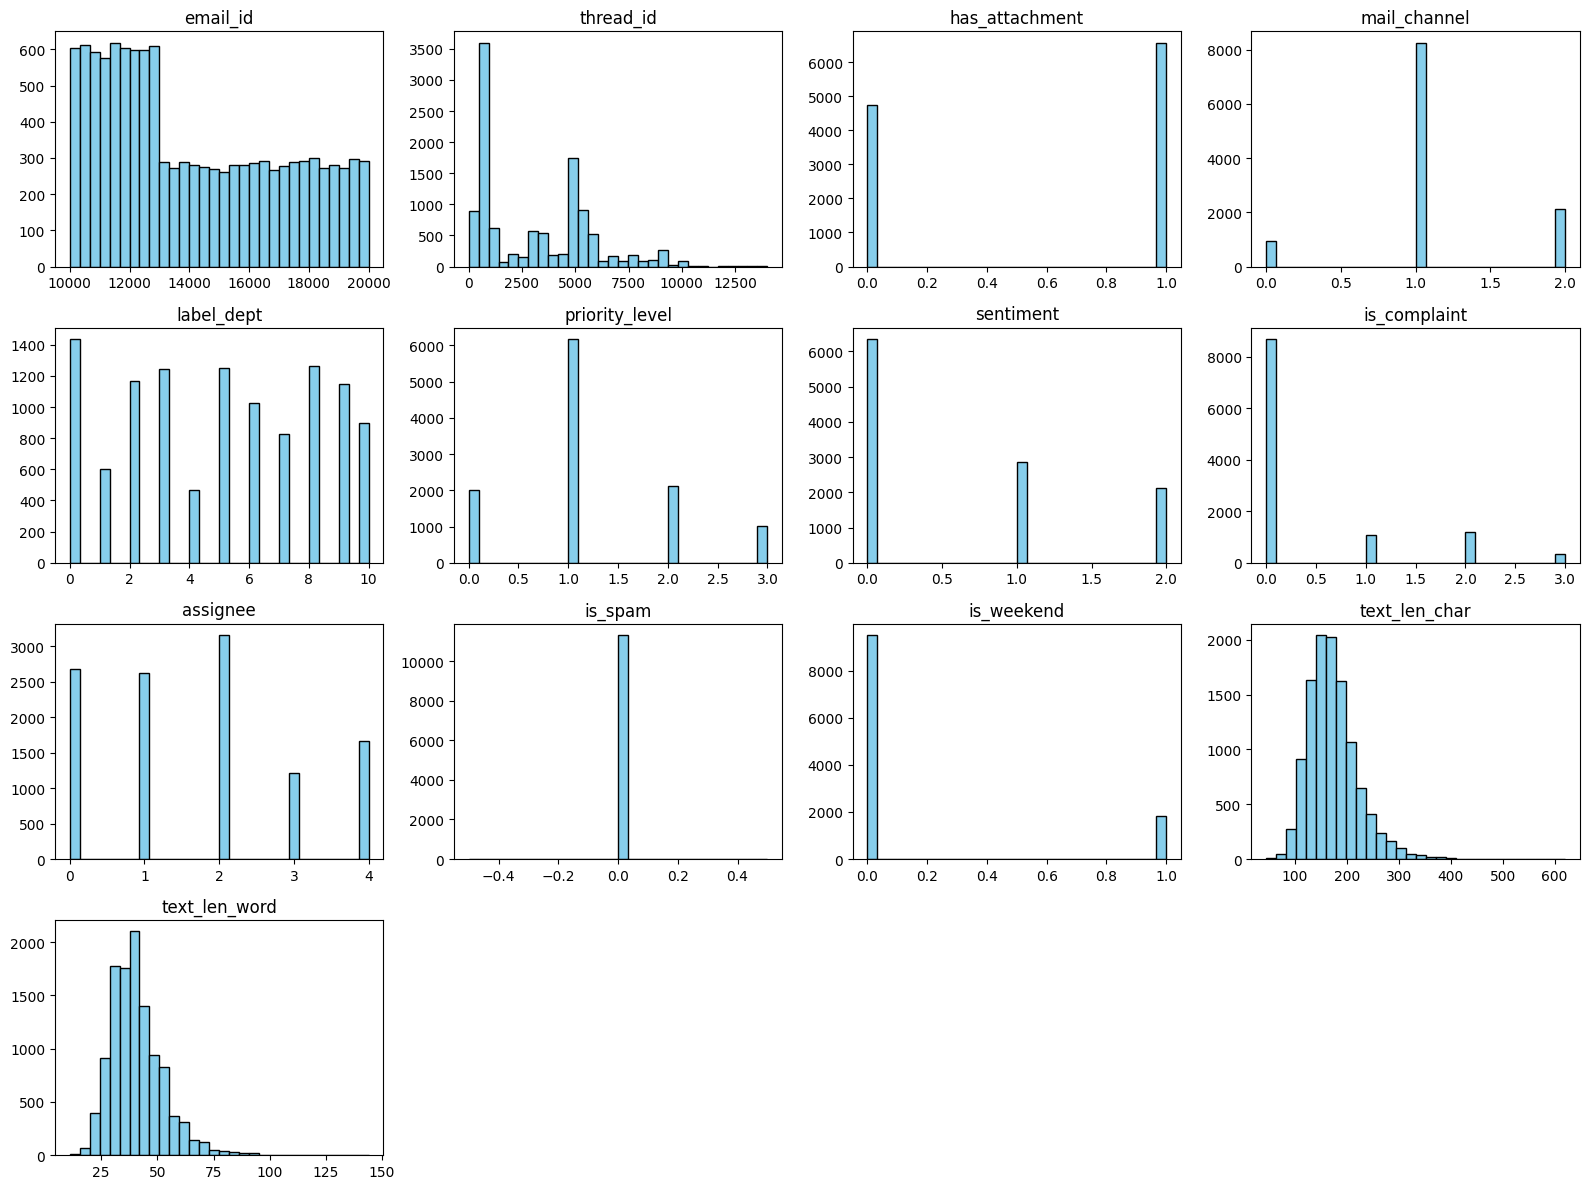

In [27]:
num_cols = df_normal.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(16, 12))
df_normal[num_cols].hist(
    bins=30,
    figsize=(16, 12),
    grid=False,
    edgecolor='black',
    color='skyblue'
)
plt.tight_layout()
plt.show()

<Figure size 1600x1200 with 0 Axes>

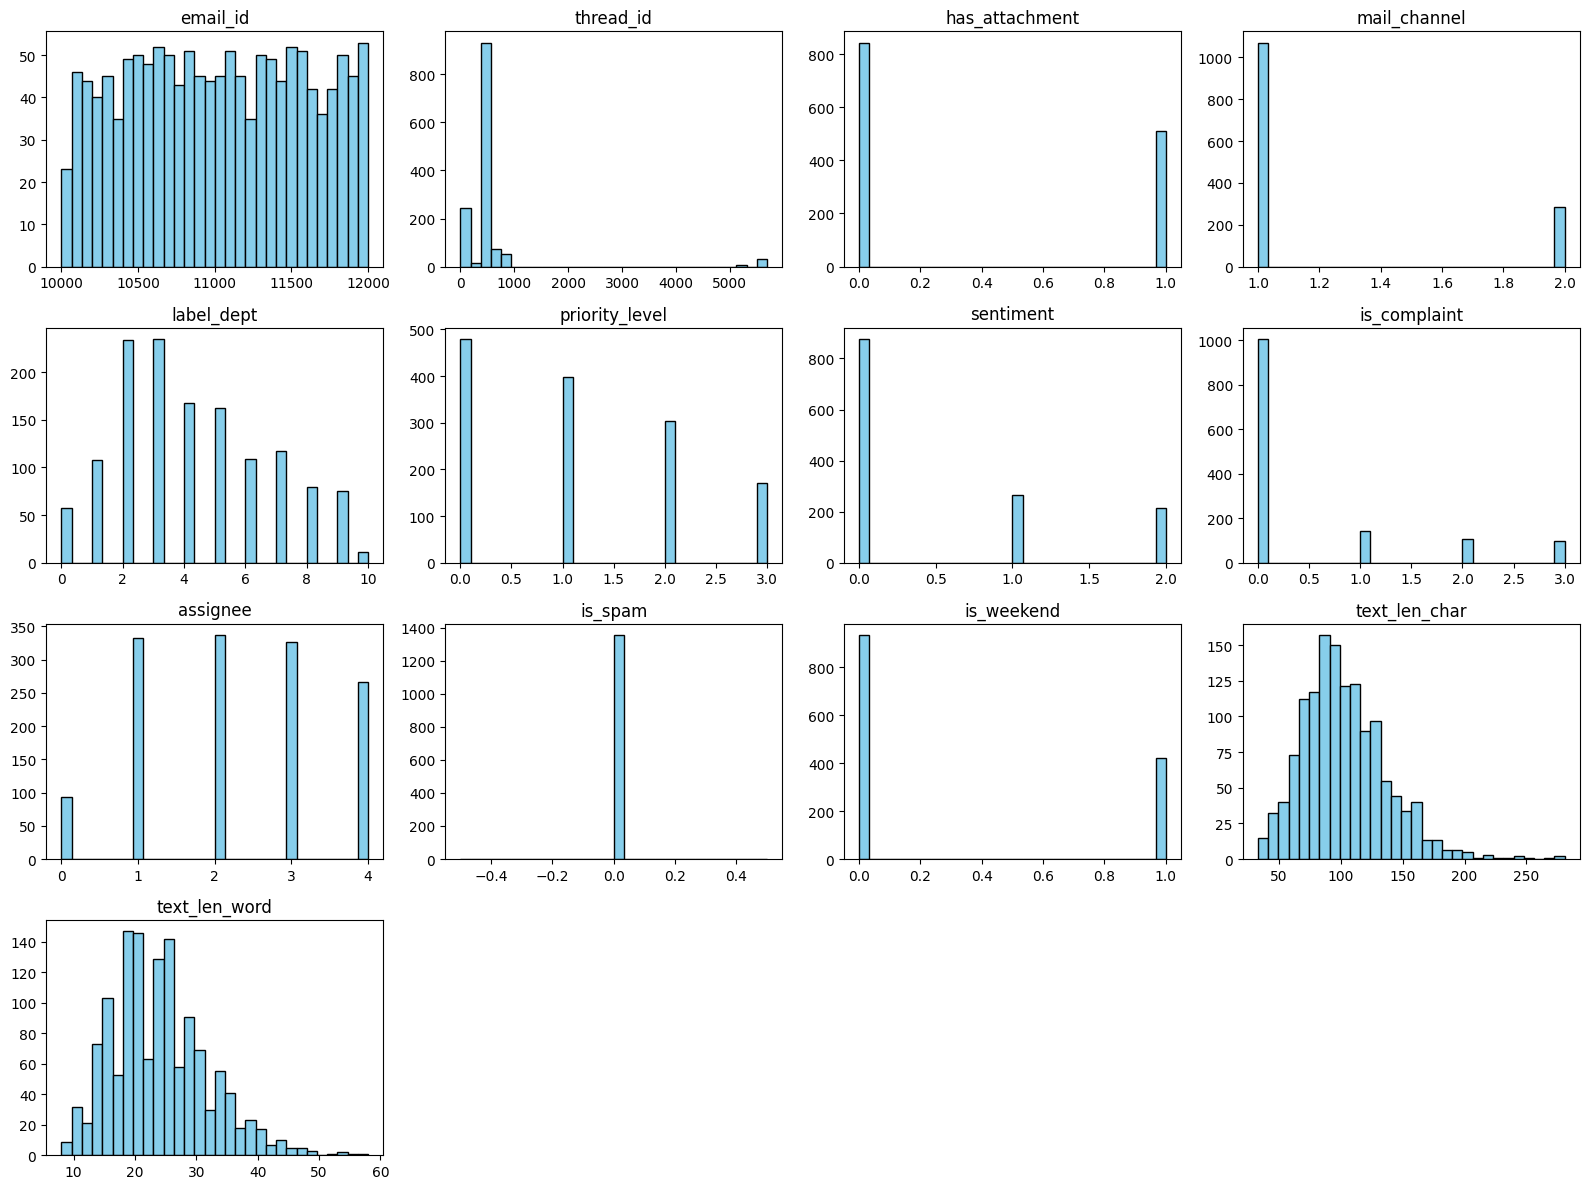

In [28]:
num_cols = df_raw_normal.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(16, 12))
df_raw_normal[num_cols].hist(
    bins=30,
    figsize=(16, 12),
    grid=False,
    edgecolor='black',
    color='skyblue'
)
plt.tight_layout()
plt.show()

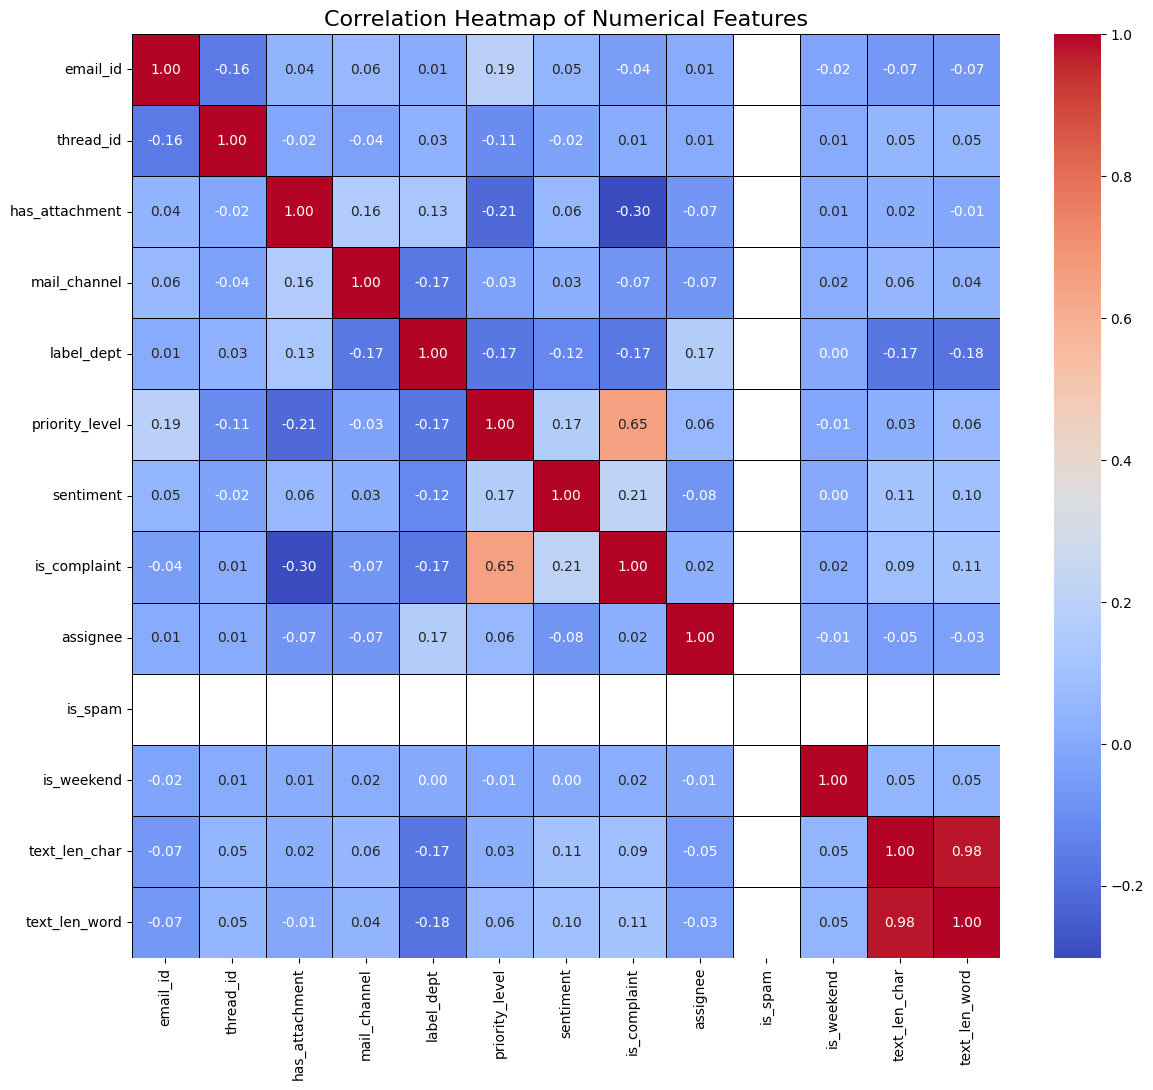

In [29]:
# 1. 수치형 컬럼 선택 (이전 코드에서 이미 수행되었을 수 있지만 안전하게 다시 실행)
num_cols = df_normal.select_dtypes(include=['int64', 'float64']).columns
df_numeric = df_normal[num_cols]

# 2. 상관 관계 행렬 계산
correlation_matrix = df_numeric.corr()

# 3. 히트맵 생성
plt.figure(figsize=(14, 12)) # 플롯 크기 설정
sns.heatmap(
    correlation_matrix,
    annot=True,        # 셀 안에 상관계수 값 표시
    fmt=".2f",         # 표시되는 값을 소수점 둘째 자리까지 포맷
    cmap='coolwarm',   # 색상 맵 설정 (양의 상관관계는 'warm', 음의 상관관계는 'cool' 계열)
    cbar=True,         # 컬러 바 표시
    linewidths=0.5,    # 셀 사이의 간격
    linecolor='black'  # 셀 사이의 선 색상
)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.show()

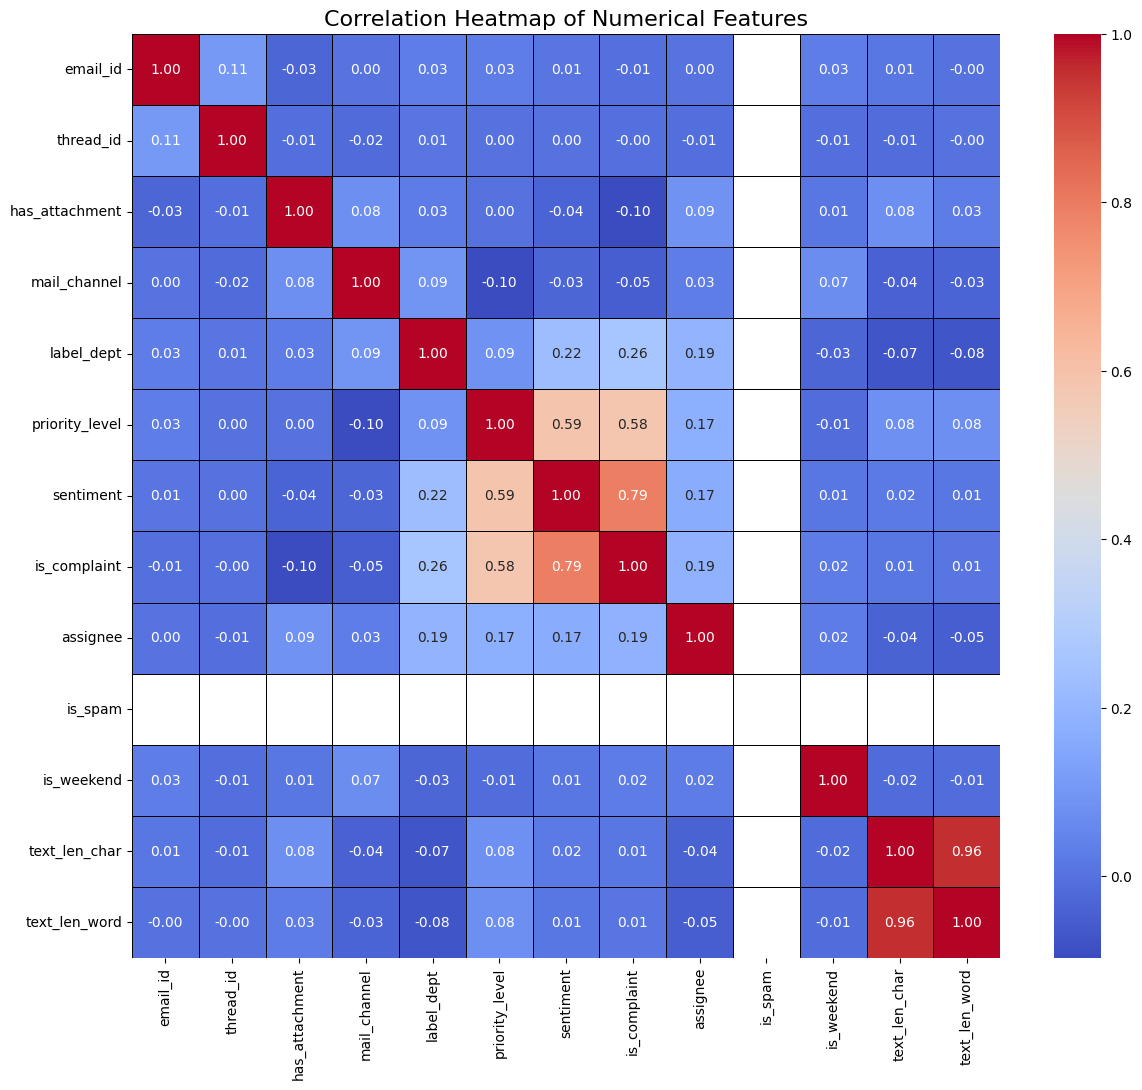

In [30]:
# 1. 수치형 컬럼 선택 (이전 코드에서 이미 수행되었을 수 있지만 안전하게 다시 실행)
num_cols = df_raw_normal.select_dtypes(include=['int64', 'float64']).columns
df_numeric = df_raw_normal[num_cols]

# 2. 상관 관계 행렬 계산
correlation_matrix = df_numeric.corr()

# 3. 히트맵 생성
plt.figure(figsize=(14, 12)) # 플롯 크기 설정
sns.heatmap(
    correlation_matrix,
    annot=True,        # 셀 안에 상관계수 값 표시
    fmt=".2f",         # 표시되는 값을 소수점 둘째 자리까지 포맷
    cmap='coolwarm',   # 색상 맵 설정 (양의 상관관계는 'warm', 음의 상관관계는 'cool' 계열)
    cbar=True,         # 컬러 바 표시
    linewidths=0.5,    # 셀 사이의 간격
    linecolor='black'  # 셀 사이의 선 색상
)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.show()

In [31]:
df_normal.head(1)

,email_id,thread_id,received_at,sender,recipient,title,content,has_attachment,mail_channel,label_dept,...,sentiment,is_complaint,assignee,is_spam,text,hour,dayofweek,is_weekend,text_len_char,text_len_word
0,10001,1,2024-07-10 10:00:00,dev.seojun@ssacorp.com,service.minji@ssacorp.com,API 서버 에러 로그 분석 요청,"안녕하세요, 서비스팀 민지님. 어제부터 API 서버에서 간헐적으로 에러가 발생하고 ...",1,1,0,...,1,0,0,0,"API 서버 에러 로그 분석 요청 안녕하세요, 서비스팀 민지님. 어제부터 API 서...",10,2,0,132,29


## 필요한 컬럼 분류

* email_id, thread_id > 시계열용 index 해당 모델은 시계열 모델이 아니므로 drop
* received_at > hour/dayofweek로만 사용
* sender, recipient > 스팸, 성실도 모델에서는 그룹핑해야하기에 필요하지만 텍스트 분류 모델에서는 의미가 적음
* is_spam > 이미 스팸이 아닌 데이터 기준으로 학습 진행
* title, content > text에 한번에 처리

In [32]:
label_cols = [
    'mail_channel',
    'label_dept',
    'priority_level',
    'sentiment',
    'is_complaint',
    'assignee'
]

Y = {col: df_normal[col].values for col in label_cols}
Y_raw = {col: df_raw_normal[col].values for col in label_cols}

In [33]:
X_text = df_normal['text'].values  # 메인 텍스트 입력
X_raw_text = df_raw_normal['text'].values  # 메인 텍스트 입력

In [34]:
# X_tcon = df_normal[['title','content']].copy()
# X_raw_tcon = df_raw_normal[['title','content']].copy()

In [35]:
extra_cols = [
    'title',
    'content',
    'has_attachment',
    'hour',
    'dayofweek',
    'is_weekend',
    'text_len_char',
    'text_len_word'
]
X_extra = df_normal[extra_cols].values
X_raw_extra = df_raw_normal[extra_cols].values

## 결측 및 이상치 최종정리
* test길이가 5미만으로 너무 짧은것은 제거

In [36]:
needed_cols = ['text',
    'mail_channel','label_dept','priority_level',
    'sentiment','is_complaint','assignee'
]

df_model = df_normal.dropna(subset=needed_cols).copy()
df_model = df_model[df_model['text'].str.len() > 5].copy()
df_model.head(1)

df_raw_model = df_raw_normal.dropna(subset=needed_cols).copy()
df_raw_model = df_raw_model[df_raw_model['text'].str.len() > 5].copy()
df_raw_model.head(1)

,email_id,thread_id,received_at,sender,recipient,title,content,has_attachment,mail_channel,label_dept,...,sentiment,is_complaint,assignee,is_spam,text,hour,dayofweek,is_weekend,text_len_char,text_len_word
15,10571,1,2025-01-28 15:20:18,john.doe@ssacorp.com,jane.smith@ssacorp.com,RE: 보고서 검토 요청,"제인, 안녕하세요. 보내주신 보고서 잘 받았습니다. 3페이지의 데이터가 좀 이상한 ...",1,1,2,...,0,0,1,0,"RE: 보고서 검토 요청 제인, 안녕하세요. 보내주신 보고서 잘 받았습니다. 3페이...",15,1,0,124,27


박스플롯 대상 컬럼: ['email_id', 'thread_id', 'has_attachment', 'is_weekend', 'text_len_char', 'text_len_word']


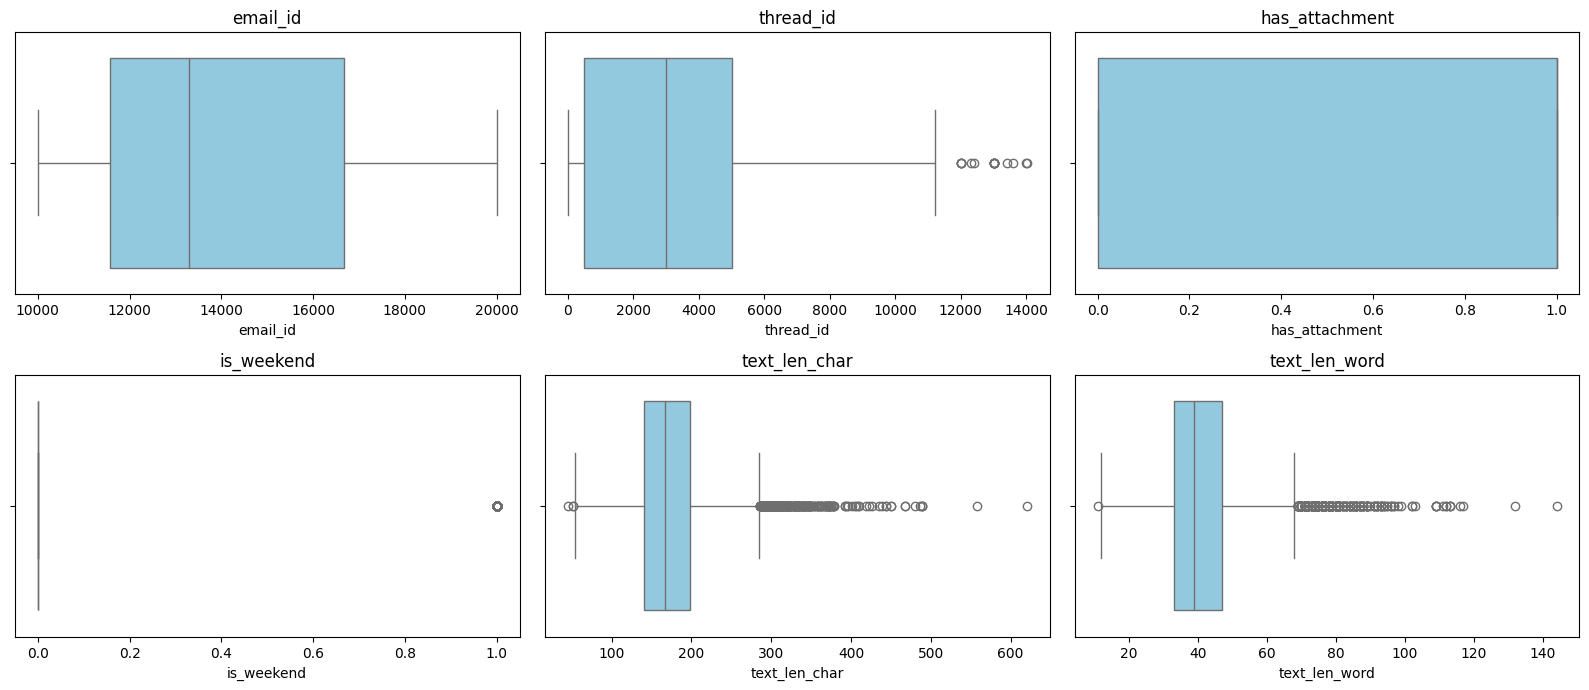

In [37]:
# 1) 숫자형 컬럼 자동 선택
num_cols = df_normal.select_dtypes(include=['int64', 'float64']).columns

# 자주 안 쓰는 라벨값 제외 (뷰를 깔끔하게 하고 싶으면)
exclude = ['mail_channel','label_dept','priority_level','sentiment','is_complaint','assignee','is_spam']
num_cols = [c for c in num_cols if c not in exclude]

print("박스플롯 대상 컬럼:", num_cols)

# 2) Subplot으로 박스플롯 그리기
plt.figure(figsize=(16, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot( (len(num_cols)//3 + 1), 3, i)
    sns.boxplot(x=df_normal[col], color='skyblue')
    plt.title(col)

plt.tight_layout()
plt.show()


박스플롯 대상 컬럼: ['email_id', 'thread_id', 'has_attachment', 'is_weekend', 'text_len_char', 'text_len_word']


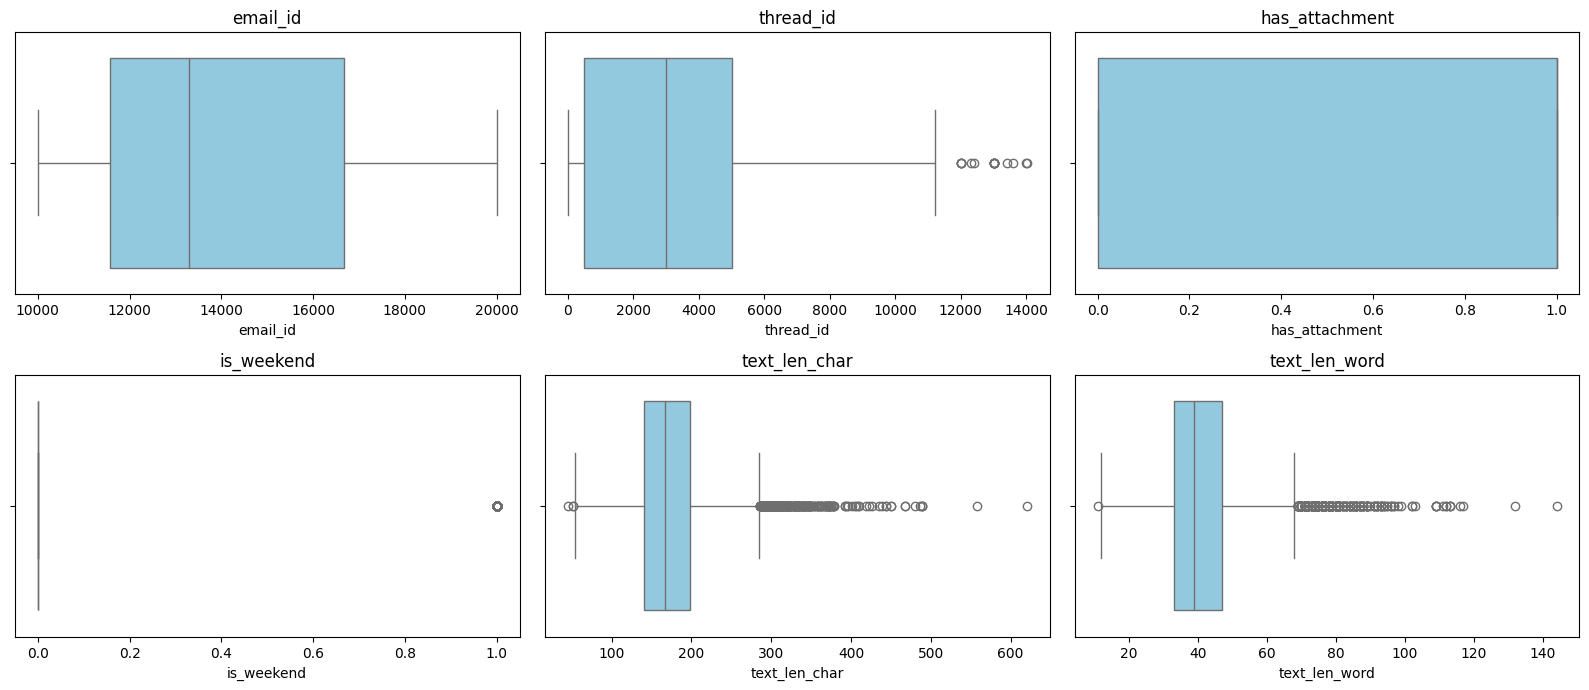

In [38]:
# 1) 숫자형 컬럼 자동 선택
num_cols = df_raw_normal.select_dtypes(include=['int64', 'float64']).columns

# 자주 안 쓰는 라벨값 제외 (뷰를 깔끔하게 하고 싶으면)
exclude = ['mail_channel','label_dept','priority_level','sentiment','is_complaint','assignee','is_spam']
num_cols = [c for c in num_cols if c not in exclude]

print("박스플롯 대상 컬럼:", num_cols)

# 2) Subplot으로 박스플롯 그리기
plt.figure(figsize=(16, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot( (len(num_cols)//3 + 1), 3, i)
    sns.boxplot(x=df_normal[col], color='skyblue')
    plt.title(col)

plt.tight_layout()
plt.show()


## train_test_split

In [39]:
# extra 컬럼 정의 (원하는 대로 추가/변경 가능)
extra_cols = [
    'title',
    'content',
    'has_attachment',
    'hour',
    'dayofweek',
    'is_weekend',
    'text_len_char',
    'text_len_word'
]

# 텍스트 + extra 합치기
X = df_model[['text'] + extra_cols].copy()

# 라벨 6개
label_cols = [
    'mail_channel', 'label_dept', 'priority_level',
    'sentiment', 'is_complaint', 'assignee'
]
y = df_model[label_cols].copy()
X_raw = df_raw_model[['text'] + extra_cols].copy()
y_raw = df_raw_model[label_cols].copy()

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y['label_dept']   
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((9064, 9), (2267, 9), (9064, 6), (2267, 6))

In [41]:
X_train

,text,title,content,has_attachment,hour,dayofweek,is_weekend,text_len_char,text_len_word
87,"신규 랜딩 페이지 시안 검토 요청 은지님, 안녕하세요. 디자인팀 김미희입니다. 신규...",신규 랜딩 페이지 시안 검토 요청,"은지님, 안녕하세요. 디자인팀 김미희입니다. 신규 랜딩 페이지 시안을 제작 완료하여...",1,10,6,1,138,33
7357,"견적 요청에 대한 답변 - 프로젝트 Rainbow 안녕하세요, 김지훈님. 프로젝트 ...",견적 요청에 대한 답변 - 프로젝트 Rainbow,"안녕하세요, 김지훈님.\r\n프로젝트 Rainbow 견적 요청에 대한 답변을 첨부 ...",1,14,6,1,234,51
9471,"협조 요청: 채용 박람회 참가 지원 박현우 님, 다음 달에 개최되는 채용 박람회에 ...",협조 요청: 채용 박람회 참가 지원,"박현우 님,\r\n\r\n다음 달에 개최되는 채용 박람회에 우리 회사도 참가할 예정...",1,10,1,0,196,48
1435,"긴급: 서버 장애 발생 - 즉각 대응 필요 개발팀 서준님, 안녕하세요. 서비스팀 민...",긴급: 서버 장애 발생 - 즉각 대응 필요,"개발팀 서준님, 안녕하세요. 서비스팀 민지입니다. 현재 서버에 장애가 발생하여 서비...",0,8,0,0,144,36
4437,"11월 비용 정산 요청 안녕하세요, 운영팀 지민님. 11월 비용 정산 관련하여 안내...",11월 비용 정산 요청,"안녕하세요, 운영팀 지민님. 11월 비용 정산 관련하여 안내드립니다. 모든 팀원은 ...",0,11,0,0,148,34
...,...,...,...,...,...,...,...,...,...
3497,"신규 랜딩 페이지 시안 전달 마케팅팀 하영님, 요청하신 신규 랜딩 페이지 시안을 전...",신규 랜딩 페이지 시안 전달,"마케팅팀 하영님,\r\n\r\n요청하신 신규 랜딩 페이지 시안을 전달드립니다. UX...",1,13,2,0,171,35
1800,"디자인팀 UX/UI 개선 시안 검토 요청 이현우님, UX/UI 개선 시안 검토 요청...",디자인팀 UX/UI 개선 시안 검토 요청,"이현우님,\r\nUX/UI 개선 시안 검토 요청드립니다. 사용자 경험 향상을 위해 ...",1,11,4,0,178,39
1652,"5월 급여 명세서 안내 이민호님, 안녕하세요. 5월 급여 명세서가 발송되었습니다. ...",5월 급여 명세서 안내,"이민호님, 안녕하세요. 5월 급여 명세서가 발송되었습니다. 첨부 파일을 확인해주시기...",1,9,1,0,88,18
956,"신규 기능 개발 요구사항 정의 서준님, 신규 기능 개발 관련하여 요구사항 정의서를 ...",신규 기능 개발 요구사항 정의,"서준님, 신규 기능 개발 관련하여 요구사항 정의서를 전달드립니다. 개발 일정 및 리...",1,16,0,0,122,31


## 텍스트 클린업 함수, mecab 형태소
* 특수문자, 중복공백, 줄바꿈, 잡스러운 문장 구조 제거
* 기본적인 전처리

In [42]:
# ! pip install python-mecab-ko

In [43]:
import pandas as pd
import re
from mecab import MeCab  # 설치한 라이브러리 import

# 1. 아까 만드신 청소 함수
def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'<[^>]+>', ' ', text)          # 태그 제거
    text = re.sub(r'(http|https)://\S+', ' ', text) # URL 제거
    text = re.sub(r'\n+', ' ', text)              # 개행 제거
    text = re.sub(r'[^a-z0-9가-힣\s]', ' ', text) # 특수문자 제거
    text = re.sub(r'\s+', ' ', text)              # 공백 정리
    return text.strip().lower()

# ==========================================
# [중요] Mecab 적용하는 곳 (위치: 전처리 후 ~ 벡터화 전)
# ==========================================

# 2. Mecab 객체 생성
mecab = MeCab()

# 3. 형태소 분석 함수 정의 (명사만 뽑을지, 전체 형태소를 뽑을지 결정)
def morph_text(text):
    # 방법 A: 명사만 추출 (키워드 분석, 주제 분류에 유리)
    # return " ".join(mecab.nouns(text))
    
    # 방법 B: 모든 형태소 추출 (문맥 파악, 감성 분석, 이메일 분류에 유리 -> 추천)
    return " ".join(mecab.morphs(text))

# 4. 데이터프레임에 적용 (X_train, X_test, X_raw 모두!)
# 먼저 청소(clean)하고 -> 그 다음 쪼개기(morph)
X_train['cleaned_text'] = X_train['text'].apply(clean_text)
X_test['cleaned_text'] = X_test['text'].apply(clean_text)
X_raw['cleaned_text'] = X_raw['text'].apply(clean_text)
X_train['title'] = X_train['title'].apply(clean_text)
X_train['content'] = X_train['content'].apply(clean_text)
X_test['title'] = X_test['title'].apply(clean_text)
X_test['content'] = X_test['content'].apply(clean_text)
X_raw['title'] = X_raw['title'].apply(clean_text)
X_raw['content'] = X_raw['content'].apply(clean_text)

print("1차 청소 완료. Mecab 형태소 분석 시작...")

X_train['processed_text'] = X_train['cleaned_text'].apply(morph_text)
X_test['processed_text'] = X_test['cleaned_text'].apply(morph_text)
X_raw['processed_text'] = X_raw['cleaned_text'].apply(morph_text)
X_train['title'] = X_train['title'].apply(morph_text)
X_train['content'] = X_train['content'].apply(morph_text)
X_test['title'] = X_test['title'].apply(morph_text)
X_test['content'] = X_test['content'].apply(morph_text)
X_raw['title'] = X_raw['title'].apply(morph_text)
X_raw['content'] = X_raw['content'].apply(morph_text)

print("Mecab 처리 완료! (예시: '아버지가 방에' -> '아버지 가 방 에')")

1차 청소 완료. Mecab 형태소 분석 시작...
Mecab 처리 완료! (예시: '아버지가 방에' -> '아버지 가 방 에')


## title, content 따로보관

In [44]:
X_train_tcon = X_train[['title', 'content']].copy()
X_test_tcon  = X_test[['title', 'content']].copy()
X_raw_tcon   = X_raw[['title', 'content']].copy()

In [45]:
# 2) 원래 데이터프레임에서 title/content 제거
X_train = X_train.drop(columns=['title', 'content'])
X_test  = X_test.drop(columns=['title', 'content'])
X_raw   = X_raw.drop(columns=['title', 'content'])

In [46]:
X_train.head(2)

,text,has_attachment,hour,dayofweek,is_weekend,text_len_char,text_len_word,cleaned_text,processed_text
87,"신규 랜딩 페이지 시안 검토 요청 은지님, 안녕하세요. 디자인팀 김미희입니다. 신규...",1,10,6,1,138,33,신규 랜딩 페이지 시안 검토 요청 은지님 안녕하세요 디자인팀 김미희입니다 신규 랜딩...,신규 랜딩 페이지 시안 검토 요청 은지 님 안녕 하 세요 디자인 팀 김미희 입니다 ...
7357,"견적 요청에 대한 답변 - 프로젝트 Rainbow 안녕하세요, 김지훈님. 프로젝트 ...",1,14,6,1,234,51,견적 요청에 대한 답변 프로젝트 ainbow 안녕하세요 김지훈님 프로젝트 ainbo...,견적 요청 에 대한 답변 프로젝트 ainbow 안녕 하 세요 김지훈 님 프로젝트 a...


In [47]:
X_raw.head(2)

,text,has_attachment,hour,dayofweek,is_weekend,text_len_char,text_len_word,cleaned_text,processed_text
15,"RE: 보고서 검토 요청 제인, 안녕하세요. 보내주신 보고서 잘 받았습니다. 3페이...",1,15,1,0,124,27,보고서 검토 요청 제인 안녕하세요 보내주신 보고서 잘 받았습니다 3페이지의 데이터가...,보고서 검토 요청 제인 안녕 하 세요 보내 주 신 보고서 잘 받 았 습니다 3 페이...
16,"RE: 프로젝트 업데이트 제인, 업데이트 고마워. 혹시 이번 주 금요일 회의에서 논...",0,10,0,0,111,28,프로젝트 업데이트 제인 업데이트 고마워 혹시 이번 주 금요일 회의에서 논의할 다른 ...,프로젝트 업데이트 제인 업데이트 고마워 혹시 이번 주 금요일 회의 에서 논의 할 다...


In [48]:
X_train_tcon

,title,content
87,신규 랜딩 페이지 시안 검토 요청,은지 님 안녕 하 세요 디자인 팀 김미희 입니다 신규 랜딩 페이지 시안 을 제작 완...
7357,견적 요청 에 대한 답변 프로젝트 ainbow,안녕 하 세요 김지훈 님 프로젝트 ainbow 견적 요청 에 대한 답변 을 첨부 파...
9471,협조 요청 채용 박람회 참가 지원,박현우 님 다음 달 에 개최 되 는 채용 박람회 에 우리 회사 도 참가 할 예정 입...
1435,긴급 서버 장애 발생 즉각 대응 필요,개발 팀 서준 님 안녕 하 세요 서비스 팀 민지 입니다 현재 서버 에 장애 가 발생...
4437,11 월 비용 정산 요청,안녕 하 세요 운영 팀 지민 님 11 월 비용 정산 관련 하 여 안 내 드립니다 모...
...,...,...
3497,신규 랜딩 페이지 시안 전달,마케팅 팀 하영 님 요청 하 신 신규 랜딩 페이지 시안 을 전달 드립니다 디자인 가...
1800,디자인 팀 개선 시안 검토 요청,이현우 님 개선 시안 검토 요청 드립니다 사용 자 경험 향상 을 위해 메인 페이지 ...
1652,5 월 급여 명세서 안내,이민호 님 안녕 하 세요 5 월 급여 명세서 가 발송 되 었 습니다 첨부 파일 을 ...
956,신규 기능 개발 요구 사항 정의,서준 님 신규 기능 개발 관련 하 여 요구사항 정의 서 를 전달 드립니다 개발 일정...


## TF-IDF 벡터
* 첫번째 돌릴 baseline 모델용

In [49]:
# [Case 1] 머신러닝용 (TF-IDF 사용 O)
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1,2), min_df=2)

# 주의: 원본 'text'가 아니라 Mecab 처리된 'processed_text'를 넣어야 함
tfidf_train = tfidf.fit_transform(X_train['processed_text'])
tfidf_test = tfidf.transform(X_test['processed_text'])
tfidf_raw = tfidf.transform(X_raw['processed_text'])

## LSTM 모델용 tokenizer + padding
* 두번째 돌릴 DL 용

In [50]:
# ! pip install tensorflow

In [51]:
# [Case 2] 딥러닝(LSTM)용 (TF-IDF 사용 X, Tokenizer 사용 O)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=30000, oov_token='<UNK>')

# 여기도 'processed_text'를 넣습니다.
tokenizer.fit_on_texts(X_train['processed_text'])

train_sequences = tokenizer.texts_to_sequences(X_train['processed_text'])
test_sequences = tokenizer.texts_to_sequences(X_test['processed_text'])
raw_sequences = tokenizer.texts_to_sequences(X_raw['processed_text'])

# Padding (앞에서 말씀드린 pre 방식)
X_train_seq = pad_sequences(train_sequences, maxlen=400, padding='pre', truncating='post')
X_test_seq = pad_sequences(test_sequences, maxlen=400, padding='pre', truncating='post')
X_raw_seq = pad_sequences(raw_sequences, maxlen=400, padding='pre', truncating='post')

X_train_seq.shape, X_test_seq.shape, X_raw_seq.shape

2025-12-09 12:04:34.242482: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-09 12:04:34.310281: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-09 12:04:35.577969: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


((9064, 400), (2267, 400), (1355, 400))

## numeric feature 스케일링

In [52]:
from sklearn.preprocessing import StandardScaler
extra_cols = [    
    'has_attachment',
    'hour',
    'dayofweek',
    'is_weekend',
    'text_len_char',
    'text_len_word'
]

scaler = StandardScaler()
scaler.fit(X_train[extra_cols])

X_train_extra_scaled = scaler.transform(X_train[extra_cols])
X_test_extra_scaled = scaler.transform(X_test[extra_cols])
X_raw_extra_scaled = scaler.transform(X_raw[extra_cols])

# ML

## Train, Test

In [53]:
task_cols = [
    'mail_channel',
    'label_dept',
    'priority_level',
    'sentiment',
    'is_complaint',
    'assignee'
]

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, f1_score

logit_results = {}

for col in task_cols:
    print(f'\n===== {col} 모델 학습 =====')

    clf = LogisticRegression(
        max_iter=1000,
        n_jobs=-1
    )
    clf.fit(tfidf_train, y_train[col])

    y_pred = clf.predict(tfidf_test)

    f1 = f1_score(y_test[col], y_pred, average='macro')
    logit_results[col] = f1

    print(f'[LogReg] {col:15s} macro F1 = {f1:.4f}')


===== mail_channel 모델 학습 =====
[LogReg] mail_channel    macro F1 = 0.6197

===== label_dept 모델 학습 =====
[LogReg] label_dept      macro F1 = 0.8610

===== priority_level 모델 학습 =====
[LogReg] priority_level  macro F1 = 0.6859

===== sentiment 모델 학습 =====
[LogReg] sentiment       macro F1 = 0.8257

===== is_complaint 모델 학습 =====
[LogReg] is_complaint    macro F1 = 0.5340

===== assignee 모델 학습 =====
[LogReg] assignee        macro F1 = 0.3484


In [55]:
# 1. 기본 import
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.base import clone
import pandas as pd

# 2. XGBoost / LightGBM 설치 여부 체크
has_xgb = False
has_lgbm = False

try:
    from xgboost import XGBClassifier
    has_xgb = True
except ImportError:
    print('[INFO] xgboost 미설치 → XGBoost 모델은 스킵됩니다. (pip install xgboost)')

try:
    from lightgbm import LGBMClassifier
    has_lgbm = True
except ImportError:
    print('[INFO] lightgbm 미설치 → LightGBM 모델은 스킵됩니다. (pip install lightgbm)')

# 3. 타겟 컬럼들 (SANAI multi-task)
task_cols = [
    'mail_channel',
    'label_dept',
    'priority_level',
    'sentiment',
    'is_complaint',
    'assignee'
]

# 4. 모델들 정의
models = {
    'LogReg': LogisticRegression(max_iter=1000, n_jobs=-1),
    'LinearSVC': LinearSVC(),
    'MultinomialNB': MultinomialNB(),
    'SGD-hinge': SGDClassifier(loss='hinge', max_iter=1000),
    'SGD-log': SGDClassifier(loss='log_loss', max_iter=1000),
    'RandomForest': RandomForestClassifier(
        n_estimators=150,
        max_depth=None,
        n_jobs=-1
    )
}

if has_xgb:
    models['XGBoost'] = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method='hist',   # GPU 없을 때도 빠른 편
        n_jobs=-1,
        objective='multi:softmax'  # 다중분류용, 하지만 여기선 task별로 다시 바뀜
    )

if has_lgbm:
    models['LightGBM'] = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

# 5. 결과 저장 딕셔너리
results = {model_name: {} for model_name in models.keys()}

# 6. 전체 모델 × 전체 태스크 학습 & macro F1 계산
for model_name, model in models.items():
    print(f'\n===== {model_name} =====')

    for col in task_cols:
        clf = clone(model)

        # XGBoost objective는 클래스 개수에 맞춰 수정 (multi:softmax / binary:logistic 등)
        if has_xgb and model_name == 'XGBoost':
            num_classes = y_train[col].nunique()
            if num_classes == 2:
                clf.set_params(objective='binary:logistic')
            else:
                clf.set_params(objective='multi:softmax', num_class=num_classes)

        clf.fit(tfidf_train, y_train[col])
        y_pred = clf.predict(tfidf_test)

        f1 = f1_score(y_test[col], y_pred, average='macro')
        results[model_name][col] = f1

        print(f'{col:15s} macro F1 = {f1:.4f}')

# 7. 최종 결과 테이블
df_f1 = pd.DataFrame(results).T
df_f1


[INFO] xgboost 미설치 → XGBoost 모델은 스킵됩니다. (pip install xgboost)
[INFO] lightgbm 미설치 → LightGBM 모델은 스킵됩니다. (pip install lightgbm)

===== LogReg =====
mail_channel    macro F1 = 0.6197
label_dept      macro F1 = 0.8610
priority_level  macro F1 = 0.6859
sentiment       macro F1 = 0.8257
is_complaint    macro F1 = 0.5340
assignee        macro F1 = 0.3484

===== LinearSVC =====
mail_channel    macro F1 = 0.6699
label_dept      macro F1 = 0.8715
priority_level  macro F1 = 0.7067
sentiment       macro F1 = 0.8259
is_complaint    macro F1 = 0.6082
assignee        macro F1 = 0.3598

===== MultinomialNB =====
mail_channel    macro F1 = 0.5672
label_dept      macro F1 = 0.8241
priority_level  macro F1 = 0.6029
sentiment       macro F1 = 0.7730
is_complaint    macro F1 = 0.4087
assignee        macro F1 = 0.3147

===== SGD-hinge =====
mail_channel    macro F1 = 0.6337
label_dept      macro F1 = 0.8730
priority_level  macro F1 = 0.6992
sentiment       macro F1 = 0.8230
is_complaint    macro F1 = 0.568

,mail_channel,label_dept,priority_level,sentiment,is_complaint,assignee
LogReg,0.619687,0.861013,0.685917,0.825704,0.534029,0.348405
LinearSVC,0.669950,0.871520,0.706724,0.825885,0.608233,0.359835
MultinomialNB,0.567210,0.824125,0.602919,0.772999,0.408722,0.314706
SGD-hinge,0.633652,0.872982,0.699212,0.822982,0.568406,0.350011
SGD-log,0.602604,0.858028,0.675602,0.815370,0.486633,0.339908
RandomForest,0.603551,0.852597,0.640340,0.799124,0.481061,0.337686


/tmp/ipykernel_5765/617275925.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


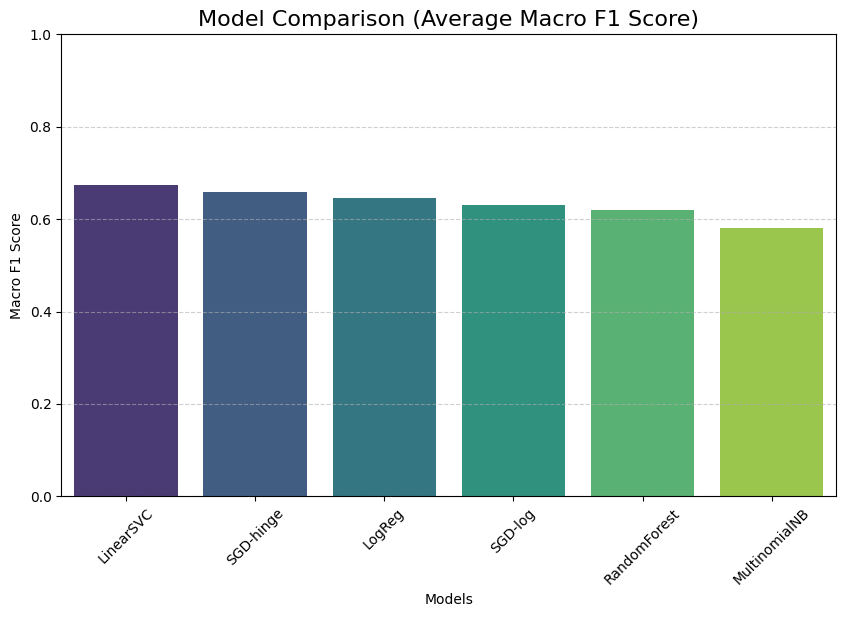

In [56]:
plt.figure(figsize=(10, 6))

df_f1['mean_f1'] = df_f1.mean(axis=1)  # 모델별 평균 macro F1

sns.barplot(
    data=df_f1.sort_values('mean_f1', ascending=False),
    x=df_f1.sort_values('mean_f1', ascending=False).index,
    y='mean_f1',
    palette='viridis'
)

plt.title('Model Comparison (Average Macro F1 Score)', fontsize=16)
plt.ylabel('Macro F1 Score')
plt.xlabel('Models')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()


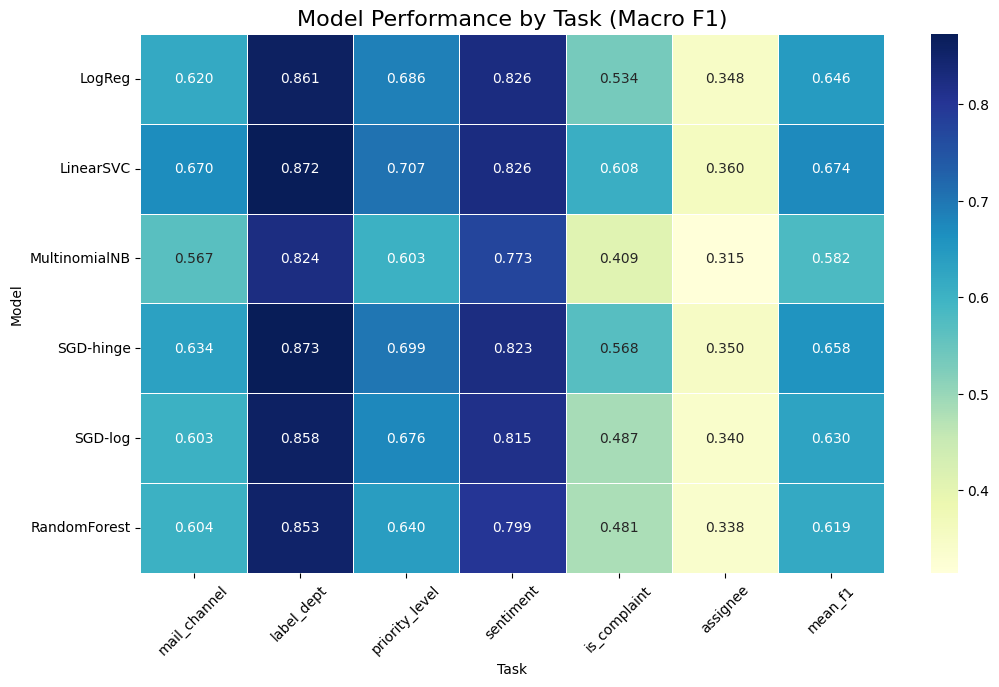

In [57]:
plt.figure(figsize=(12, 7))
sns.heatmap(
    df_f1,
    annot=True,
    fmt='.3f',
    cmap='YlGnBu',
    linewidths=.5
)

plt.title('Model Performance by Task (Macro F1)', fontsize=16)
plt.ylabel('Model')
plt.xlabel('Task')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()


## raw데이터 예측

In [58]:
# 1. raw 평가 결과 저장 딕셔너리
results_raw = {model_name: {} for model_name in models.keys()}

# 2. 전체 모델 × 전체 태스크에 대해
from sklearn.metrics import f1_score
from sklearn.base import clone

for model_name, model in models.items():
    print(f'\n===== {model_name} (RAW 평가) =====')

    for col in task_cols:
        clf = clone(model)

        # XGBoost는 클래스 개수에 맞춰 objective 설정
        if has_xgb and model_name == 'XGBoost':
            num_classes = y_train[col].nunique()  # 학습 데이터 기준
            if num_classes == 2:
                clf.set_params(objective='binary:logistic', num_class=None)
            else:
                clf.set_params(objective='multi:softmax', num_class=num_classes)

        # 학습은 그대로 tfidf_train + y_train
        clf.fit(tfidf_train, y_train[col])

        # ★ raw 데이터로 예측
        y_raw_pred = clf.predict(tfidf_raw)

        # raw 라벨과의 macro F1
        f1_raw = f1_score(y_raw[col], y_raw_pred, average='macro')
        results_raw[model_name][col] = f1_raw

        print(f'{col:15s} RAW macro F1 = {f1_raw:.4f}')

# 3. raw 평가 결과 테이블
df_f1_raw = pd.DataFrame(results_raw).T
df_f1_raw



===== LogReg (RAW 평가) =====
mail_channel    RAW macro F1 = 0.2784
label_dept      RAW macro F1 = 0.0652
priority_level  RAW macro F1 = 0.3253
sentiment       RAW macro F1 = 0.3834
is_complaint    RAW macro F1 = 0.3950
assignee        RAW macro F1 = 0.1596

===== LinearSVC (RAW 평가) =====
mail_channel    RAW macro F1 = 0.2618
label_dept      RAW macro F1 = 0.0648
priority_level  RAW macro F1 = 0.3916
sentiment       RAW macro F1 = 0.3970
is_complaint    RAW macro F1 = 0.4683
assignee        RAW macro F1 = 0.1891

===== MultinomialNB (RAW 평가) =====
mail_channel    RAW macro F1 = 0.4316
label_dept      RAW macro F1 = 0.0680
priority_level  RAW macro F1 = 0.3567
sentiment       RAW macro F1 = 0.3914
is_complaint    RAW macro F1 = 0.3188
assignee        RAW macro F1 = 0.1439

===== SGD-hinge (RAW 평가) =====
mail_channel    RAW macro F1 = 0.2714
label_dept      RAW macro F1 = 0.0630
priority_level  RAW macro F1 = 0.3910
sentiment       RAW macro F1 = 0.3991
is_complaint    RAW macro F1 = 0.49

,mail_channel,label_dept,priority_level,sentiment,is_complaint,assignee
LogReg,0.278383,0.065192,0.325268,0.383395,0.395000,0.159601
LinearSVC,0.261752,0.064750,0.391609,0.397009,0.468296,0.189095
MultinomialNB,0.431560,0.067966,0.356737,0.391401,0.318819,0.143858
SGD-hinge,0.271407,0.063026,0.391014,0.399120,0.495338,0.176650
SGD-log,0.281510,0.064760,0.339697,0.391133,0.378061,0.161150
RandomForest,0.280030,0.058635,0.267937,0.371698,0.325005,0.162379


# DL
* LSTM

## Train, Test

In [59]:
from tensorflow.keras import layers, Model, Input

vocab_size = 20000      # 🔹줄이기
embedding_dim = 128
lstm_units = 128
max_len = 400
num_extra = X_train_extra_scaled.shape[1]

# 1) 텍스트 입력
input_seq = Input(shape=(max_len,), name='input_text')
x = layers.Embedding(vocab_size, embedding_dim, mask_zero=True)(input_seq)
# 시퀀스 정보를 조금 더 뽑고, GlobalMaxPool로 요약
x = layers.Bidirectional(
        layers.LSTM(lstm_units, return_sequences=True)
    )(x)
x = layers.GlobalMaxPooling1D()(x)
x = layers.Dropout(0.2)(x)

# 2) extra feature 입력 (조금 더 얕게)
input_extra = Input(shape=(num_extra,), name='input_extra')
e = layers.Dense(32, activation='relu')(input_extra)
e = layers.Dropout(0.2)(e)

# 3) 둘을 합치고, shared tower 하나 거치기
h = layers.concatenate([x, e])
h = layers.Dense(128, activation='relu')(h)
h = layers.Dropout(0.3)(h)

# 4) 멀티태스크 헤드들 (그대로 사용)
mail = layers.Dense(3, activation='softmax', name='mail_channel')(h)
dept = layers.Dense(11, activation='softmax', name='label_dept')(h)
prio = layers.Dense(4, activation='softmax', name='priority_level')(h)
sent = layers.Dense(3, activation='softmax', name='sentiment')(h)
comp = layers.Dense(4, activation='softmax', name='is_complaint')(h)
assi = layers.Dense(5, activation='softmax', name='assignee')(h)

model = Model(
    inputs=[input_seq, input_extra],
    outputs=[mail, dept, prio, sent, comp, assi]
)


2025-12-09 12:05:39.236798: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'global_max_pooling1d' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


In [60]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    'best_lstm_multitask.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1
)

In [61]:
losses = {
    'mail_channel': 'sparse_categorical_crossentropy',
    'label_dept': 'sparse_categorical_crossentropy',
    'priority_level': 'sparse_categorical_crossentropy',
    'sentiment': 'sparse_categorical_crossentropy',
    'is_complaint': 'sparse_categorical_crossentropy',
    'assignee': 'sparse_categorical_crossentropy'
}

loss_weights = {
    'mail_channel': 0.7,
    'label_dept': 1.2,      # 🔺조금 더 중요하게
    'priority_level': 1.3,  # 🔺
    'sentiment': 0.8,
    'is_complaint': 1.3,    # 🔺
    'assignee': 0.7
}

model.compile(
    optimizer='adam',
    loss=losses,
    loss_weights=loss_weights,
    metrics={k: 'accuracy' for k in losses.keys()}
)


In [62]:
# history = model.fit(
#     [X_train_seq, X_train_extra_scaled],
#     {
#         'mail_channel':  y_train['mail_channel'].values,
#         'label_dept':    y_train['label_dept'].values,
#         'priority_level':y_train['priority_level'].values,
#         'sentiment':     y_train['sentiment'].values,
#         'is_complaint':  y_train['is_complaint'].values,
#         'assignee':      y_train['assignee'].values
#     },
#     epochs=40,
#     batch_size=64,
#     validation_split=0.1,
#     callbacks=[checkpoint, early_stop, reduce_lr],
#     verbose=1
# )

In [63]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, classification_report
from tensorflow.keras.models import load_model

# 1) 모델 로드
lstm_model = load_model('best_lstm_multitask.keras')

# 2) 입력 개수 확인
n_inputs = len(lstm_model.inputs)
print('모델 입력 개수:', n_inputs)

# 3) input 준비
#    - 1개면: 텍스트만
#    - 2개면: [텍스트, extra] 둘 다
if n_inputs == 1:
    X_test_for_model = X_test_seq
elif n_inputs == 2:
    X_test_for_model = [X_test_seq, X_test_extra_scaled]
else:
    raise ValueError(f'예상치 못한 입력 개수: {n_inputs}')

# 4) 예측
preds = lstm_model.predict(X_test_for_model, batch_size=64)

# 5) 멀티태스크 라벨들
task_cols = [
    'mail_channel',
    'label_dept',
    'priority_level',
    'sentiment',
    'is_complaint',
    'assignee'
]

lstm_f1 = {}

for i, col in enumerate(task_cols):
    y_true = y_test[col].values
    y_prob = preds[i]                # (N, num_classes)
    y_pred = np.argmax(y_prob, axis=1)

    f1 = f1_score(y_true, y_pred, average='macro')
    lstm_f1[col] = f1

    print(f'\n===== {col} =====')
    print(f'LSTM macro F1 = {f1:.4f}')
    print(classification_report(y_true, y_pred))

# 6) F1 결과 정리
df_f1_lstm = pd.Series(lstm_f1, name='LSTM_model').to_frame().T
df_f1_lstm


모델 입력 개수: 2
 1/36 ━━━━━━━━━━━━━━━━━━━━ 14s 417ms/step

2025-12-09 12:05:40.095249: E tensorflow/core/util/util.cc:131] oneDNN supports DT_BOOL only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 147ms/step

===== mail_channel =====
LSTM macro F1 = 0.5996
              precision    recall  f1-score   support

           0       0.70      0.03      0.07       205
           1       0.87      0.96      0.91      1627
           2       0.80      0.85      0.82       435

    accuracy                           0.85      2267
   macro avg       0.79      0.61      0.60      2267
weighted avg       0.84      0.85      0.82      2267


===== label_dept =====
LSTM macro F1 = 0.8553
              precision    recall  f1-score   support

           0       0.84      0.81      0.83       288
           1       0.66      0.67      0.67       121
           2       0.90      0.84      0.87       234
           3       0.92      0.91      0.91       249
           4       0.91      0.87      0.89        94
           5       0.92      0.95      0.93       250
           6       0.83      0.83      0.83       205
           7       0.74      0.67      0.70      

,mail_channel,label_dept,priority_level,sentiment,is_complaint,assignee
LSTM_model,0.599582,0.855319,0.720912,0.806292,0.531563,0.283781


In [64]:
# 예: df_f1_ml: 행=모델명, 열=task (macro F1)
# 예전에 만든 results -> df_f1 이런 식으로 되어 있으면 이름 맞춰서 사용

df_compare = pd.concat([df_f1, df_f1_lstm], axis=0)
df_compare


,mail_channel,label_dept,priority_level,sentiment,is_complaint,assignee,mean_f1
LogReg,0.619687,0.861013,0.685917,0.825704,0.534029,0.348405,0.645793
LinearSVC,0.669950,0.871520,0.706724,0.825885,0.608233,0.359835,0.673691
MultinomialNB,0.567210,0.824125,0.602919,0.772999,0.408722,0.314706,0.581780
SGD-hinge,0.633652,0.872982,0.699212,0.822982,0.568406,0.350011,0.657874
SGD-log,0.602604,0.858028,0.675602,0.815370,0.486633,0.339908,0.629691
RandomForest,0.603551,0.852597,0.640340,0.799124,0.481061,0.337686,0.619060
LSTM_model,0.599582,0.855319,0.720912,0.806292,0.531563,0.283781,NaN


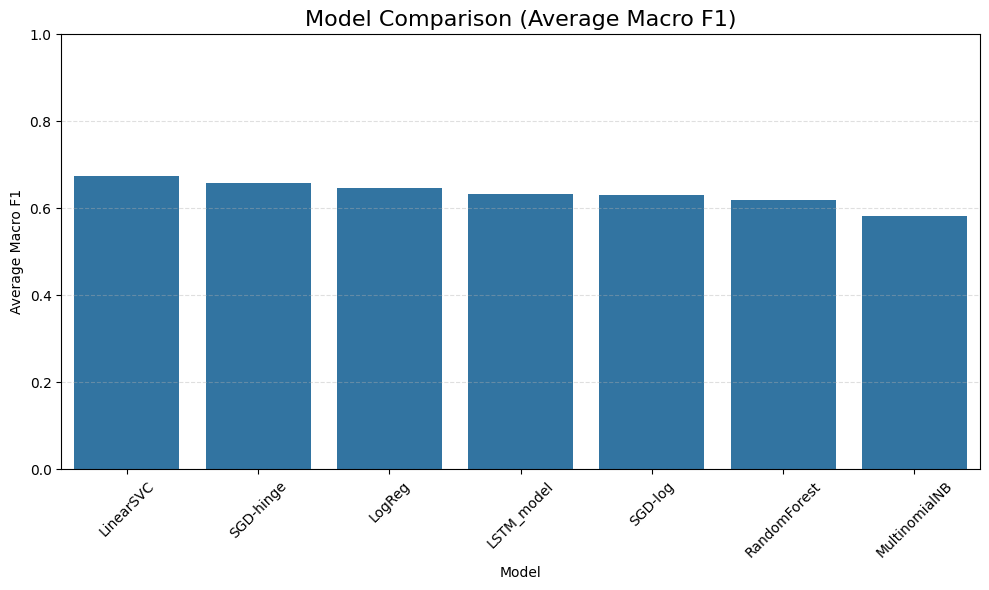

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# 모델별 평균 macro F1 계산
df_compare_mean = df_compare.copy()
df_compare_mean['mean_macro_f1'] = df_compare_mean.mean(axis=1)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_compare_mean.sort_values('mean_macro_f1', ascending=False).reset_index(),
    x='index',
    y='mean_macro_f1'
)
plt.title('Model Comparison (Average Macro F1)', fontsize=16)
plt.xlabel('Model')
plt.ylabel('Average Macro F1')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


## raw 데이터 예측

In [66]:
# 1) 모델 로드
lstm_model = load_model('best_lstm_multitask.keras')

# 2) 모델 입력 개수 확인
n_inputs = len(lstm_model.inputs)
print('모델 입력 개수:', n_inputs)

# 3) raw 입력 준비
#    - 1개면: 텍스트 시퀀스만
#    - 2개면: [텍스트 시퀀스, extra features]
if n_inputs == 1:
    X_raw_for_model = X_raw_seq
elif n_inputs == 2:
    X_raw_for_model = [X_raw_seq, X_raw_extra_scaled]
else:
    raise ValueError(f'예상치 못한 입력 개수: {n_inputs}')

# 4) 예측 (raw 데이터를 모델에 넣기)
raw_preds = lstm_model.predict(X_raw_for_model, batch_size=64)

# 5) 멀티태스크 라벨들
task_cols = [
    'mail_channel',
    'label_dept',
    'priority_level',
    'sentiment',
    'is_complaint',
    'assignee'
]

# df_raw_model에서 y_raw 만들었었다고 가정
y_raw = df_raw_model[task_cols].copy()

lstm_f1_raw = {}

# 6) 각 태스크별 성능 출력
for i, col in enumerate(task_cols):
    y_true = y_raw[col].values
    y_prob = raw_preds[i]
    y_pred = np.argmax(y_prob, axis=1)

    f1 = f1_score(y_true, y_pred, average='macro')
    lstm_f1_raw[col] = f1

    print(f'\n===== RAW {col} =====')
    print(f'LSTM RAW macro F1 = {f1:.4f}')
    print(classification_report(y_true, y_pred))

# 8) Accuracy + F1 점수 계산 후 저장
lstm_scores_raw = {}

for i, col in enumerate(task_cols):
    y_true = y_raw[col].values
    y_prob = raw_preds[i]
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')

    lstm_scores_raw[col] = {
        'accuracy': acc,
        'f1_macro': f1
    }

# 9) 점수 한눈에 보기
print('\n=========== RAW LSTM SCORE (ACC + F1) ===========')
for col, scores in lstm_scores_raw.items():
    print(f'{col:15s} | acc: {scores["accuracy"]:.4f} | f1: {scores["f1_macro"]:.4f}')

# 7) 최종 성능 테이블
df_f1_lstm_raw = pd.Series(lstm_f1_raw, name='LSTM_raw_result').to_frame().T
df_f1_lstm_raw

/usr/local/lib/python3.10/dist-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'global_max_pooling1d' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


모델 입력 개수: 2
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step

===== RAW mail_channel =====
LSTM RAW macro F1 = 0.2532
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.72      0.54      0.62      1071
           2       0.11      0.19      0.14       284

    accuracy                           0.47      1355
   macro avg       0.28      0.25      0.25      1355
weighted avg       0.59      0.47      0.52      1355


===== RAW label_dept =====
LSTM RAW macro F1 = 0.0644
              precision    recall  f1-score   support

           0       0.01      0.04      0.02        57
           1       0.03      0.06      0.04       108
           2       0.17      0.09      0.12       234
           3       0.29      0.11      0.16       235
           4       0.01      0.01      0.01       168
           5       0.11      0.16      0.13       162
           6       0.03      0.06      0.04       109
           7       0.

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_clas

,mail_channel,label_dept,priority_level,sentiment,is_complaint,assignee
LSTM_raw_result,0.253161,0.064392,0.376369,0.383363,0.384498,0.144923


# DL 수정 버전
<pre>
                   ┌─ title_input → Embedding → LSTM(64)
content_input → Embedding → BiLSTM(128) → Attention ───┤
                                                       ↓concat
                     extra_input → Dense(128) → Dropout ─┘
                                 ↓
                           Dense(256)
                                 ↓
            ┌────────── mail_channel_head
            ├────────── label_dept_head
            ├────────── priority_head
            ├────────── sentiment_head
            ├────────── complaint_head
            └────────── assignee_head


## text 칼럼 드랍, 다시 title, content 나눈 칼럼으로
* 형태소 이미 분리되어 있음
* 클린업까지 마친 상태
* 이제 워드 임베딩 들어가면 되는 상태임

In [67]:
def rebuild_text_column(df, df_tcon):
    df = df.drop(columns=['text'], errors='ignore').copy()
    df = df.drop(columns=['cleaned_text'], errors='ignore').copy()
    df = df.drop(columns=['processed_text'], errors='ignore').copy()
    df['title'] = df_tcon['title']
    df['content'] = df_tcon['content']
    return df

In [68]:
X_train = rebuild_text_column(X_train, X_train_tcon)
X_test  = rebuild_text_column(X_test, X_test_tcon)
X_raw   = rebuild_text_column(X_raw, X_raw_tcon)

In [69]:
X_train

,has_attachment,hour,dayofweek,is_weekend,text_len_char,text_len_word,title,content
87,1,10,6,1,138,33,신규 랜딩 페이지 시안 검토 요청,은지 님 안녕 하 세요 디자인 팀 김미희 입니다 신규 랜딩 페이지 시안 을 제작 완...
7357,1,14,6,1,234,51,견적 요청 에 대한 답변 프로젝트 ainbow,안녕 하 세요 김지훈 님 프로젝트 ainbow 견적 요청 에 대한 답변 을 첨부 파...
9471,1,10,1,0,196,48,협조 요청 채용 박람회 참가 지원,박현우 님 다음 달 에 개최 되 는 채용 박람회 에 우리 회사 도 참가 할 예정 입...
1435,0,8,0,0,144,36,긴급 서버 장애 발생 즉각 대응 필요,개발 팀 서준 님 안녕 하 세요 서비스 팀 민지 입니다 현재 서버 에 장애 가 발생...
4437,0,11,0,0,148,34,11 월 비용 정산 요청,안녕 하 세요 운영 팀 지민 님 11 월 비용 정산 관련 하 여 안 내 드립니다 모...
...,...,...,...,...,...,...,...,...
3497,1,13,2,0,171,35,신규 랜딩 페이지 시안 전달,마케팅 팀 하영 님 요청 하 신 신규 랜딩 페이지 시안 을 전달 드립니다 디자인 가...
1800,1,11,4,0,178,39,디자인 팀 개선 시안 검토 요청,이현우 님 개선 시안 검토 요청 드립니다 사용 자 경험 향상 을 위해 메인 페이지 ...
1652,1,9,1,0,88,18,5 월 급여 명세서 안내,이민호 님 안녕 하 세요 5 월 급여 명세서 가 발송 되 었 습니다 첨부 파일 을 ...
956,1,16,0,0,122,31,신규 기능 개발 요구 사항 정의,서준 님 신규 기능 개발 관련 하 여 요구사항 정의 서 를 전달 드립니다 개발 일정...


In [70]:
len(X_train),len(y_train), len(X_test),len(y_test)

(9064, 9064, 2267, 2267)

## 하이퍼 파라미터

In [71]:
vocab_size      = 50000   # 토크나이저 vocab
embedding_dim   = 128
title_max_len   = 40      # 제목은 짧게
content_max_len = 256     # 본문은 256 정도로 줄이자
lstm_units      = 128

batch_size = 64
epochs     = 20

## Word2Vec 학습

In [72]:
# ! pip install gensim

In [73]:
from gensim.models import Word2Vec

# 제목 + 본문 모두 합쳐서 전체 corpus 구성
all_texts = (
    X_train['title'].astype(str).tolist()
    + X_train['content'].astype(str).tolist()
    + X_test['title'].astype(str).tolist()
    + X_test['content'].astype(str).tolist()
    + X_raw['title'].astype(str).tolist()
    + X_raw['content'].astype(str).tolist()
)

# mecab에서 이미 '토큰1 토큰2 …' 형태로 나왔으므로 split() 하면 단어 리스트가 됨
sentences = [text.split() for text in all_texts]

print("총 문장 수:", len(sentences))
print("샘플 문장:", sentences[0][:20])

총 문장 수: 25372
샘플 문장: ['신규', '랜딩', '페이지', '시안', '검토', '요청']


In [74]:
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=128,   # 너의 embedding_dim과 동일해야 함
    window=5,
    min_count=2,       # 너무 드문 단어 제거
    workers=8,         # 멀티코어 최대 활용
    sg=1,              # Skip-gram (도메인 특화 상황에 강함)
    epochs=10          # 데이터에 따라 5~20까지 가능
)

print("Word2Vec 학습 완료!")

Word2Vec 학습 완료!


In [75]:
w2v_model.save("word2vec_sanai.model")
print("모델 저장 완료: word2vec_sanai.model")

모델 저장 완료: word2vec_sanai.model


## TOKENIZER

In [76]:
# 토크나이저는 title + content 전체에 대해 한 번만 학습
train_texts = (
    X_train['title'].astype(str).tolist()
    + X_train['content'].astype(str).tolist()
)

tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(train_texts)

## PADDING

In [77]:
def make_seq(df, col, max_len):
    texts = df[col].astype(str).tolist()
    seqs  = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=max_len, padding='post', truncating='post')

X_train_title_seq   = make_seq(X_train, 'title',   title_max_len)
X_test_title_seq    = make_seq(X_test,  'title',   title_max_len)
X_raw_title_seq    = make_seq(X_raw,  'title',   title_max_len)

X_train_content_seq = make_seq(X_train, 'content', content_max_len)
X_test_content_seq  = make_seq(X_test,  'content', content_max_len)
X_raw_content_seq  = make_seq(X_raw,  'content', content_max_len)


## EXTRA FEATURE

In [78]:
X_train_extra_scaled = scaler.transform(X_train[extra_cols])
X_test_extra_scaled = scaler.transform(X_test[extra_cols])
X_raw_extra_scaled = scaler.transform(X_raw[extra_cols])

In [79]:
num_extra = X_train_extra_scaled.shape[1]

## y 라벨 > DICT

In [80]:
task_cols = [
    'mail_channel',
    'label_dept',
    'priority_level',
    'sentiment',
    'is_complaint',
    'assignee'
]

y_train_dict = {}
y_test_dict  = {}

for col in task_cols:
    y_train_dict[col] = y_train[col].values  # y_train은 기존에 나눠둔 라벨 DF/Series
    y_test_dict[col]  = y_test[col].values


## Word2Vec / FastText 임베딩

In [81]:
from gensim.models import Word2Vec  # 또는 FastText

# 예: 저장해둔 w2v 모델 로드
w2v_model = Word2Vec.load('word2vec_sanai.model')

embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, idx in tokenizer.word_index.items():
    if idx >= vocab_size:
        continue
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]
    else:
        # OOV는 0 벡터 그대로 두거나 랜덤 초기화 가능
        pass

## 모델

### attention layer

In [82]:
class Attention(layers.Layer):
    def __init__(self, **kwargs):
        # trainable, name, dtype 같은 Keras 기본 인자들을 모두 받아서 부모로 넘김
        super(Attention, self).__init__(**kwargs)

    def call(self, hidden_states):
        # hidden_states: (batch, seq_len, hidden_dim)
        score = tf.nn.tanh(hidden_states)
        attention_weights = tf.nn.softmax(score, axis=1)   # (batch, seq_len, hidden_dim)
        context_vector = attention_weights * hidden_states # (batch, seq_len, hidden_dim)
        context_vector = tf.reduce_sum(context_vector, axis=1)  # (batch, hidden_dim)
        return context_vector

    def get_config(self):
        # 나중에 필요하면 이 안에 하이퍼파라미터 추가 가능
        config = super(Attention, self).get_config()
        return config


### 입력 정의

In [83]:
# 1) title 입력
title_input = Input(shape=(title_max_len,), name='title_input')

# 2) content 입력
content_input = Input(shape=(content_max_len,), name='content_input')

# 3) extra feature 입력
extra_input = Input(shape=(num_extra,), name='extra_input')

### 임베딩 레이어

In [84]:
if 'embedding_matrix' in globals():
    title_emb = layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=title_max_len,
        trainable=True,
        mask_zero=True,
        name='title_embedding'
    )(title_input)

    content_emb = layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=content_max_len,
        trainable=True,
        mask_zero=True,
        name='content_embedding'
    )(content_input)
else:
    # 프리트레인 없음 - 랜덤 초기화
    title_emb = layers.Embedding(
        vocab_size, embedding_dim,
        input_length=title_max_len,
        mask_zero=True,
        name='title_embedding'
    )(title_input)

    content_emb = layers.Embedding(
        vocab_size, embedding_dim,
        input_length=content_max_len,
        mask_zero=True,
        name='content_embedding'
    )(content_input)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


### 타이틀 브랜치

In [85]:
t = layers.LSTM(64, return_sequences=False, name='title_lstm')(title_emb)
t = layers.Dropout(0.3)(t)   # 약간만 드랍

### 컨텐츠 브랜치

In [86]:
import tensorflow as tf
c = layers.Bidirectional(
        layers.LSTM(lstm_units, return_sequences=True),
        name='content_bilstm'
    )(content_emb)

c = Attention()(c)           # (batch, hidden_dim * 2)
c = layers.Dropout(0.3)(c)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'attention' (of type Attention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


### extra feature 브랜치

In [87]:
e = layers.Dense(128, activation='relu', name='extra_dense1')(extra_input)
e = layers.BatchNormalization(name='extra_bn')(e)
e = layers.Dropout(0.3)(e)

### 3개 합치기

In [88]:
h = layers.concatenate([t, c, e], name='concat_text_extra')
h = layers.Dense(256, activation='relu', name='fusion_dense')(h)
h = layers.Dropout(0.4)(h)

### 아웃풋

In [89]:
mail_out = layers.Dense(3,  activation='softmax', name='mail_channel')(h)
dept_out = layers.Dense(11, activation='softmax', name='label_dept')(h)
prio_out = layers.Dense(4,  activation='softmax', name='priority_level')(h)
sent_out = layers.Dense(3,  activation='softmax', name='sentiment')(h)
comp_out = layers.Dense(4,  activation='softmax', name='is_complaint')(h)
assi_out = layers.Dense(5,  activation='softmax', name='assignee')(h)

model = Model(
    inputs=[title_input, content_input, extra_input],
    outputs=[mail_out, dept_out, prio_out, sent_out, comp_out, assi_out]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ content_input       │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ title_input         │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ content_embedding   │ (None, 256, 128)  │  6,400,000 │ content_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_4         │ (None, 256)       │          0 │ content_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ extra_input         │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ title_embedding     │ (None, 40, 128)   │  6,400,000 │ title_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_3         │ (None, 40)        │          0 │ title_input[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ content_bilstm      │ (None, 256, 256)  │    263,168 │ content_embeddin… │
│ (Bidirectional)     │                   │            │ not_equal_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ extra_dense1        │ (None, 128)       │        896 │ extra_input[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ title_lstm (LSTM)   │ (None, 64)        │     49,408 │ title_embedding[… │
│                     │                   │            │ not_equal_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 256)       │          0 │ content_bilstm[0… │
│ (Attention)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ extra_bn            │ (None, 128)       │        512 │ extra_dense1[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ title_lstm[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 256)       │          0 │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128)       │          0 │ extra_bn[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_text_extra   │ (None, 448)       │          0 │ dropout_3[0][0],  │
│ (Concatenate)       │                   │            │ dropout_4[0][0],  │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense        │ (None, 256)       │    114,944 │ concat_text_extr… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 13,236,638 (50.49 MB)

 Trainable params: 13,236,382 (50.49 MB)

 Non-trainable params: 256 (1.00 KB)

### loss/loss_weight 설정

In [90]:
losses = {
    'mail_channel':   'sparse_categorical_crossentropy',
    'label_dept':     'sparse_categorical_crossentropy',
    'priority_level': 'sparse_categorical_crossentropy',
    'sentiment':      'sparse_categorical_crossentropy',
    'is_complaint':   'sparse_categorical_crossentropy',
    'assignee':       'sparse_categorical_crossentropy',
}

loss_weights = {
    'mail_channel':   0.8,
    'label_dept':     1.0,
    'priority_level': 1.6,
    'sentiment':      1.5,
    'is_complaint':   1.8,
    'assignee':       1.0,
}

metrics = {
    'mail_channel':   'accuracy',
    'label_dept':     'accuracy',
    'priority_level': 'accuracy',
    'sentiment':      'accuracy',
    'is_complaint':   'accuracy',
    'assignee':       'accuracy',
}

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=losses,
    loss_weights=loss_weights,
    metrics=metrics
)

### fit

In [91]:
# X_train_inputs = {
#     'title_input':   X_train_title_seq,
#     'content_input': X_train_content_seq,
#     'extra_input':   X_train_extra_scaled,
# }

# X_test_inputs = {
#     'title_input':   X_test_title_seq,
#     'content_input': X_test_content_seq,
#     'extra_input':   X_test_extra_scaled,
# }

# callbacks = [
#     EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
#     ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
#     ModelCheckpoint('best_lstm_2nd.keras', monitor='val_loss',
#                     save_best_only=True, verbose=1)
# ]

# history = model.fit(
#     X_train_inputs,
#     y_train_dict,
#     validation_data=(X_test_inputs, y_test_dict),
#     epochs=epochs,
#     batch_size=batch_size,
#     callbacks=callbacks
# )

In [92]:
from tensorflow.keras.models import load_model

best_model = load_model(
    'best_lstm_2nd.keras',
    custom_objects={'Attention': Attention}
)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'attention_1' (of type Attention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


### 예측 평가

In [93]:
X_train_inputs = {
    'title_input':   X_train_title_seq,
    'content_input': X_train_content_seq,
    'extra_input':   X_train_extra_scaled,
}

X_test_inputs = {
    'title_input':   X_test_title_seq,
    'content_input': X_test_content_seq,
    'extra_input':   X_test_extra_scaled,
}

# 예측
preds = model.predict(X_test_inputs, batch_size=64)

# preds는 리스트 또는 dict 형태
# 각 태스크별로 argmax 해서 F1 계산하면 됨

36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 150ms/step


## 예측 성능 확인

In [94]:
task_names = [
    'mail_channel',
    'label_dept',
    'priority_level',
    'sentiment',
    'is_complaint',
    'assignee'
]

def evaluate_multitask(preds, y_test_dict):
    print("\n===== SANAI MULTITASK MODEL - TEST PERFORMANCE =====\n")

    f1_results = {}

    # preds가 리스트 형태이기 때문에 dict 형태로 변환
    pred_dict = {task_names[i]: preds[i] for i in range(len(task_names))}

    for task in task_names:
        y_true = y_test_dict[task]
        y_pred = np.argmax(pred_dict[task], axis=1)

        macro_f1 = f1_score(y_true, y_pred, average='macro')
        f1_results[task] = macro_f1

        print(f"--- {task} ---")
        print(f"Macro F1: {macro_f1:.4f}")
        print(classification_report(y_true, y_pred))
        print("-----------------------------------------------\n")

    print("===== SUMMARY (MACRO F1) =====")
    for task, score in f1_results.items():
        print(f"{task:15s} : {score:.4f}")

    return f1_results

In [95]:
evaluate_multitask(preds, y_test_dict)


===== SANAI MULTITASK MODEL - TEST PERFORMANCE =====

--- mail_channel ---
Macro F1: 0.2116
              precision    recall  f1-score   support

           0       0.10      0.53      0.17       205
           1       0.69      0.14      0.23      1627
           2       0.17      0.34      0.23       435

    accuracy                           0.22      2267
   macro avg       0.32      0.34      0.21      2267
weighted avg       0.54      0.22      0.23      2267

-----------------------------------------------

--- label_dept ---
Macro F1: 0.0292
              precision    recall  f1-score   support

           0       0.02      0.01      0.01       288
           1       0.00      0.00      0.00       121
           2       0.11      0.03      0.05       234
           3       0.06      0.18      0.09       249
           4       0.00      0.00      0.00        94
           5       0.00      0.00      0.00       250
           6       0.00      0.00      0.00       205
        

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.10/dist-packag

{'mail_channel': 0.2116426444068139,
 'label_dept': 0.02919899548521882,
 'priority_level': 0.17875726076122384,
 'sentiment': 0.30914394007905904,
 'is_complaint': 0.15782628377450386,
 'assignee': 0.18346223561693936}

## raw 데이터 예측

In [96]:
X_raw_inputs = {
    'title_input':   X_raw_title_seq,
    'content_input': X_raw_content_seq,
    'extra_input':   X_raw_extra_scaled,
}

In [97]:
# 예측
preds = model.predict(X_raw_inputs, batch_size=64)

# preds는 리스트 또는 dict 형태
# 각 태스크별로 argmax 해서 F1 계산하면 됨

22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step


In [98]:
y_raw_dict  = {}

for col in task_cols:    
    y_raw_dict[col]  = y_raw[col].values


In [99]:
evaluate_multitask(preds, y_raw_dict)


===== SANAI MULTITASK MODEL - TEST PERFORMANCE =====

--- mail_channel ---
Macro F1: 0.1239
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.88      0.01      0.01      1071
           2       0.25      0.64      0.36       284

    accuracy                           0.14      1355
   macro avg       0.37      0.21      0.12      1355
weighted avg       0.74      0.14      0.09      1355

-----------------------------------------------

--- label_dept ---
Macro F1: 0.0455
              precision    recall  f1-score   support

           0       0.04      0.04      0.04        57
           1       0.00      0.00      0.00       108
           2       0.31      0.07      0.12       234
           3       0.17      0.80      0.29       235
           4       0.00      0.00      0.00       168
           5       0.00      0.00      0.00       162
           6       0.50      0.01      0.02       109
        

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_clas

{'mail_channel': 0.12391534576209846,
 'label_dept': 0.04549766268292241,
 'priority_level': 0.1371591683708248,
 'sentiment': 0.29649919731876656,
 'is_complaint': 0.1997676179793822,
 'assignee': 0.17872706780645314}

# TRANSFORMER

In [100]:
# ! pip install transformers accelerate

## 텍스트 + EXTRA 준비

In [103]:
from transformers import AutoTokenizer, TFAutoModel

# 1) text: title + content 합치기
def build_tcon(df_tcon):
    t = df_tcon['title'].fillna('')
    c = df_tcon['content'].fillna('')
    return (t + ' [SEP] ' + c).astype(str)

X_train_text = build_tcon(X_train_tcon)
X_test_text  = build_tcon(X_test_tcon)

# 2) targets
task_cols = [
    'mail_channel',
    'label_dept',
    'priority_level',
    'sentiment',
    'is_complaint',
    'assignee'
]

y_train = y_train[task_cols].astype('int32')
y_test  = y_test[task_cols].astype('int32')

# 3) extra features (이미 스케일링 끝났다고 가정)
# 3) extra features (이미 스케일링 끝났다고 가정)
X_train_extra = X_train_extra_scaled.astype('float32')
X_test_extra  = X_test_extra_scaled.astype('float32')

num_extra = X_train_extra.shape[1]


### title + content

In [105]:
def build_tcon(df: pd.DataFrame) -> pd.Series:
    t = df['title'].fillna('')
    c = df['content'].fillna('')
    # 제목과 본문 사이에 [SEP] 하나 넣어주면 트랜스포머가 구분하기 좋음
    return (t + ' [SEP] ' + c).astype(str)

# train / test / raw 각각 텍스트 시퀀스 만들기
X_train_text = build_tcon(X_train)
X_test_text  = build_tcon(X_test)
X_raw_text   = build_tcon(X_raw)

print('예시 텍스트 1개:', X_train_text.iloc[0][:200])

예시 텍스트 1개: 신규 랜딩 페이지 시안 검토 요청 [SEP] 은지 님 안녕 하 세요 디자인 팀 김미희 입니다 신규 랜딩 페이지 시안 을 제작 완료 하 여 검토 요청 드립니다 첨부 파일 확인 후 피드백 부탁 드립니다 개선 및 레이아웃 수정 등 의견 주 시 면 적극 반영 하 겠 습니다


### y컬럼

In [106]:
task_cols = [
    'mail_channel',
    'label_dept',
    'priority_level',
    'sentiment',
    'is_complaint',
    'assignee'
]

# int32로만 맞춰주면 됨
y_train_task = y_train[task_cols].astype('int32')
y_test_task  = y_test[task_cols].astype('int32')
y_raw_task   = y_raw[task_cols].astype('int32')

# tf.data에 넣기 편하게 dict로 변환
y_train_dict = {col: y_train_task[col].values for col in task_cols}
y_test_dict  = {col: y_test_task[col].values  for col in task_cols}

### extra feature 스케일링

In [107]:
import numpy as np
from sklearn.preprocessing import StandardScaler

extra_cols = [
    'has_attachment',
    'hour',
    'dayofweek',
    'is_weekend',
    'text_len_char',
    'text_len_word'
]

scaler_extra = StandardScaler()
X_train_extra = scaler_extra.fit_transform(X_train[extra_cols])
X_test_extra  = scaler_extra.transform(X_test[extra_cols])
X_raw_extra   = scaler_extra.transform(X_raw[extra_cols])

X_train_extra = X_train_extra.astype('float32')
X_test_extra  = X_test_extra.astype('float32')
X_raw_extra   = X_raw_extra.astype('float32')

num_extra = X_train_extra.shape[1]
print('extra feature 개수:', num_extra)
print('X_train_extra shape:', X_train_extra.shape)


extra feature 개수: 6
X_train_extra shape: (9064, 6)


## TRANSFORMER 토크나이저, 인코딩
* raw는 나중에 할거임

In [113]:
from transformers import AutoTokenizer, TFAutoModel

MODEL_NAME = 'klue/bert-base'   # 나중에 바꾸고 싶으면 여기만 교체
max_len = 256                   # 메일 길이 보고 조절 가능 (256~384 정도)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_texts(texts: pd.Series):
    enc = tokenizer(
        list(texts),
        padding='max_length',
        truncation=True,
        max_length=max_len,
        return_tensors='tf'
    )
    return enc['input_ids'], enc['attention_mask']

X_train_ids, X_train_mask = tokenize_texts(X_train_text)
X_test_ids,  X_test_mask  = tokenize_texts(X_test_text)

print('X_train_ids shape:', X_train_ids.shape)
print('X_train_mask shape:', X_train_mask.shape)


X_train_ids shape: (9064, 256)
X_train_mask shape: (9064, 256)


## tf.data DATASET

In [109]:
batch_size = 16  # GPU 상태 보고 나중에 8/32로 조절 가능

# y를 dict로 변환
y_train_dict = {col: y_train_task[col].values for col in task_cols}
y_test_dict  = {col: y_test_task[col].values  for col in task_cols}

train_ds = tf.data.Dataset.from_tensor_slices((
    {
        'input_ids': X_train_ids,
        'attention_mask': X_train_mask,
        'input_extra': X_train_extra
    },
    y_train_dict
)).shuffle(len(X_train_text)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((
    {
        'input_ids': X_test_ids,
        'attention_mask': X_test_mask,
        'input_extra': X_test_extra
    },
    y_test_dict
)).batch(batch_size).prefetch(tf.data.AUTOTUNE)


## focal loss 함수

In [110]:
def make_sparse_focal_loss(n_classes, gamma=2.0, alpha=None):
    """
    n_classes: 클래스 개수
    alpha: 클래스별 가중치 리스트/배열
           예) [0.5, 1.0, 1.5, 2.0] → 높은 클래스에 더 가중치
    """
    if alpha is None:
        alpha = tf.ones((n_classes,), dtype=tf.float32)
    else:
        alpha = tf.constant(alpha, dtype=tf.float32)

    def loss(y_true, y_pred):
        # y_true: (batch,)
        y_true = tf.cast(y_true, tf.int32)
        y_true_oh = tf.one_hot(y_true, depth=n_classes)  # (batch, C)

        # log(0) 방지
        y_pred_clipped = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        ce = -y_true_oh * tf.math.log(y_pred_clipped)   # (batch, C)
        weight = alpha * tf.pow(1.0 - y_pred_clipped, gamma)
        fl = weight * ce
        fl = tf.reduce_sum(fl, axis=-1)                 # (batch,)
        return fl

    return loss

# priority_level: 0,1,2,3 → 2,3에 더 가중치
priority_focal = make_sparse_focal_loss(
    n_classes=4,
    gamma=2.0,
    alpha=[0.5, 1.0, 1.5, 2.0]
)

# is_complaint: 0,1,2,3 → 강한 불만에 더 가중치
complaint_focal = make_sparse_focal_loss(
    n_classes=4,
    gamma=2.0,
    alpha=[0.5, 1.0, 1.5, 2.0]
)


## 트랜스포머 + extra 멀티태스크 모델정의

In [ ]:
# ! pip install tf-keras

In [111]:
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam

encoder = TFAutoModel.from_pretrained(MODEL_NAME)

# 1) 텍스트 인풋
input_ids = Input(shape=(max_len,), dtype=tf.int32, name='input_ids')
attention_mask = Input(shape=(max_len,), dtype=tf.int32, name='attention_mask')

enc_out = encoder(input_ids, attention_mask=attention_mask)
cls_token = enc_out.last_hidden_state[:, 0, :]  # [CLS] 토큰

text_repr = layers.Dense(256, activation='relu')(cls_token)
text_repr = layers.Dropout(0.2)(text_repr)

# 2) extra 인풋
input_extra = Input(shape=(num_extra,), name='input_extra')
extra_repr = layers.Dense(64, activation='relu')(input_extra)
extra_repr = layers.Dropout(0.2)(extra_repr)

# 3) concat 후 공통 레이어
h = layers.concatenate([text_repr, extra_repr])
h = layers.Dense(256, activation='relu')(h)
h = layers.Dropout(0.2)(h)

# 4) 태스크별 헤드
mail_out   = layers.Dense(3,  activation='softmax', name='mail_channel')(h)
dept_out   = layers.Dense(11, activation='softmax', name='label_dept')(h)
prio_out   = layers.Dense(4,  activation='softmax', name='priority_level')(h)
sent_out   = layers.Dense(3,  activation='softmax', name='sentiment')(h)
compl_out  = layers.Dense(4,  activation='softmax', name='is_complaint')(h)
assign_out = layers.Dense(5,  activation='softmax', name='assignee')(h)

model = Model(
    inputs=[input_ids, attention_mask, input_extra],
    outputs=[mail_out, dept_out, prio_out, sent_out, compl_out, assign_out]
)

model.summary()


TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


TypeError: 'builtins.safe_open' object is not iterable

## compile + 학습

In [ ]:
losses = {
    'mail_channel':   tf.keras.losses.SparseCategoricalCrossentropy(),
    'label_dept':     tf.keras.losses.SparseCategoricalCrossentropy(),
    'priority_level': priority_focal,   # focal
    'sentiment':      tf.keras.losses.SparseCategoricalCrossentropy(),
    'is_complaint':   complaint_focal,  # focal
    'assignee':       tf.keras.losses.SparseCategoricalCrossentropy(),
}

loss_weights = {
    'mail_channel':   1.0,
    'label_dept':     1.2,
    'priority_level': 1.5,  # 중요도↑
    'sentiment':      1.0,
    'is_complaint':   1.8,  # 중요도↑
    'assignee':       1.3,
}

metrics = {name: ['accuracy'] for name in losses.keys()}

optimizer = Adam(learning_rate=2e-5)

model.compile(
    optimizer=optimizer,
    loss=losses,
    loss_weights=loss_weights,
    metrics=metrics
)


## 콜백 + fit

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=1,
        min_lr=1e-6
    ),
    ModelCheckpoint(
        'best_transformer_multitask_with_extra_focal.keras',
        monitor='val_loss',
        save_best_only=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,        # 처음엔 3~5 정도 해보고 조절
    callbacks=callbacks
)


## test 데이터 평가

In [ ]:
from sklearn.metrics import f1_score
import numpy as np

preds_test = model.predict(val_ds)
y_true = y_test_task.reset_index(drop=True)

print('=== Test macro F1 결과 ===')
for i, col in enumerate(task_cols):
    y_hat = np.argmax(preds_test[i], axis=1)
    y_true_col = y_true[col].values
    f1 = f1_score(y_true_col, y_hat, average='macro')
    print(f'{col:15s} macro F1 = {f1:.4f}')


## raw 예측

## raw 텍스트 토크나이징

In [ ]:
X_raw_ids, X_raw_mask = tokenize_texts(X_raw_text)

raw_ds = tf.data.Dataset.from_tensor_slices(
    {
        'input_ids': X_raw_ids,
        'attention_mask': X_raw_mask,
        'input_extra': X_raw_extra
    }
).batch(batch_size).prefetch(tf.data.AUTOTUNE)


## 예측 + argmax

In [ ]:
preds_raw = model.predict(raw_ds)

raw_pred_dict = {}
for i, col in enumerate(task_cols):
    raw_pred_dict[col + '_pred'] = np.argmax(preds_raw[i], axis=1)


## 원래 raw DF에 붙이기

In [ ]:
df_raw_pred = X_raw.copy()
for k, v in raw_pred_dict.items():
    df_raw_pred[k] = v

# 라벨이 이미 있는 raw라면, 비교용으로 실제값도 달 수 있음
for col in task_cols:
    df_raw_pred[col + '_true'] = y_raw_task[col].values

df_raw_pred.head()
